In [ ]:
from pathlib import Path
import json
import urllib.request
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    try:
        import ipykernel

        connection_file = Path(ipykernel.get_connection_file()).name
        kernel_id = connection_file.split('-', 1)[1].split('.', 1)[0]

        try:
            from notebook import notebookapp

            servers = list(notebookapp.list_running_servers())
        except Exception:
            from jupyter_server import serverapp

            servers = list(serverapp.list_running_servers())

        for srv in servers:
            token = srv.get('token', '')
            api_url = f"{srv['url'].rstrip('/')}/api/sessions"
            if token:
                api_url = f"{api_url}?token={token}"

            with urllib.request.urlopen(api_url, timeout=2) as response:
                sessions = json.loads(response.read().decode('utf-8'))

            for sess in sessions:
                if sess.get('kernel', {}).get('id') == kernel_id:
                    notebook_path = sess.get('notebook', {}).get('path') or sess.get('path', '')
                    raw_stem = Path(notebook_path).stem or 'notebook'
                    safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
                    return safe_stem.strip('_') or 'notebook'
    except Exception:
        pass

    return 'notebook'


if not hasattr(plt, '_trebl_autosave_original_show'):
    plt._trebl_autosave_original_show = plt.show
    plt._trebl_autosave_counter = 1
    plt._trebl_notebook_stem = _trebl_notebook_stem()

    def _trebl_autosave_show(*args, **kwargs):
        for fig_num in plt.get_fignums():
            fig = plt.figure(fig_num)
            stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
            plt._trebl_autosave_counter += 1
        return plt._trebl_autosave_original_show(*args, **kwargs)

    plt.show = _trebl_autosave_show


In [1]:
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns

In [2]:
exp = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/ChopTFs_pipeline/speed/exponential_fit_baseline_norm.csv", index_col = 0)
exp = exp[["ADseq", "t_half_model_empirical", "obs_max"]]
exp = exp.rename(columns = {"t_half_model_empirical" : "t_half_exp", 
                            "obs_max" : "obs_max_exp"})
exp

,ADseq,t_half_exp,obs_max_exp
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,2.645291,1.150497
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,5.651303,1.551581
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,6.132265,1.391873
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,8.296593,0.973756
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,6.492986,1.406179
...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,8.296593,1.426466
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,9.979960,0.982423
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,6.973948,1.471982
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,9.018036,1.143447


In [3]:
log = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/ChopTFs_pipeline/speed/logistic_fit_baseline_norm.csv", index_col = 0)
log = log[["ADseq", "t_half", "observed_strength"]]
log = log.rename(columns = {"t_half" : "t_half_log", 
                            "observed_strength" : "obs_max_log"})
log

,ADseq,t_half_log,obs_max_log
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,2.042042,1.137649
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,6.606607,1.513870
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,7.267267,1.370633
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,8.828829,0.921619
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,7.387387,1.347826
...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,9.549550,1.390677
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,10.930931,0.942420
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,8.288288,1.436320
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,10.210210,1.107947


In [4]:
hill = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/ChopTFs_pipeline/speed/hill_fit_baseline_norm.csv", index_col = 0)
hill = hill[["ADseq", "t_half_obs", "obs_max"]]
hill = hill.rename(columns = {"t_half_obs" : "t_half_hill", 
                            "obs_max" : "obs_max_hill"})
hill

,ADseq,t_half_hill,obs_max_hill
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,2.404810,1.149031
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,5.771543,1.551690
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,6.372745,1.399850
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,8.416834,0.947896
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,6.853707,1.379290
...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,8.777555,1.415576
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,10.100200,0.970270
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,7.334669,1.473238
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,9.619238,1.140620


In [5]:
first_passage_pval_class = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/ChopTFs_pipeline/speed/first_passage_pval_class.csv", index_col = 0)
first_passage_pval_class

,ADseq,first_pass_time,max_activity
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,10,1.204614
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,10,1.550627
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,10,1.411124
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,20,1.014475
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,10,1.486441
...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,10,1.453678
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,20,0.996907
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,10,1.520583
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,15,1.192689


In [6]:
first_passage_DBD = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/ChopTFs_pipeline/speed/first_passage_DBD.csv", index_col = 0)
first_passage_DBD = first_passage_DBD.rename(columns = {"first_pass_time" : "first_pass_time_DBD", "max_activity" : "max_activity_DBD"})
first_passage_DBD

,ADseq,max_activity_DBD,first_pass_time_DBD
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0.801983,15
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,1.970491,2
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,1.285137,10
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,1.191691,10
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,1.624554,10
...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,1.376673,10
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,1.136863,15
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,1.463755,10
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,1.288224,10


In [7]:
merged = pd.merge(exp, log, how = 'outer')
merged = pd.merge(merged, hill, how = 'outer')
merged = pd.merge(merged, first_passage_pval_class, how = 'outer')
merged = pd.merge(merged, first_passage_DBD, how = 'outer')
merged

,ADseq,t_half_exp,obs_max_exp,t_half_log,obs_max_log,t_half_hill,obs_max_hill,first_pass_time,max_activity,max_activity_DBD,first_pass_time_DBD
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,2.645291,1.150497,2.042042,1.137649,2.404810,1.149031,10,1.204614,0.801983,15.0
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,5.651303,1.551581,6.606607,1.513870,5.771543,1.551690,10,1.550627,1.970491,2.0
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,6.132265,1.391873,7.267267,1.370633,6.372745,1.399850,10,1.411124,1.285137,10.0
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,8.296593,0.973756,8.828829,0.921619,8.416834,0.947896,20,1.014475,1.191691,10.0
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,6.492986,1.406179,7.387387,1.347826,6.853707,1.379290,10,1.486441,1.624554,10.0
...,...,...,...,...,...,...,...,...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,8.296593,1.426466,9.549550,1.390677,8.777555,1.415576,10,1.453678,1.376673,10.0
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,9.979960,0.982423,10.930931,0.942420,10.100200,0.970270,20,0.996907,1.136863,15.0
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,6.973948,1.471982,8.288288,1.436320,7.334669,1.473238,10,1.520583,1.463755,10.0
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,9.018036,1.143447,10.210210,1.107947,9.619238,1.140620,15,1.192689,1.288224,10.0


In [8]:
# Not sharing DBD first passage times because confusing
merged_to_share = merged.drop(columns = ["max_activity_DBD", "first_pass_time_DBD"])
merged_to_share

,ADseq,t_half_exp,obs_max_exp,t_half_log,obs_max_log,t_half_hill,obs_max_hill,first_pass_time,max_activity
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,2.645291,1.150497,2.042042,1.137649,2.404810,1.149031,10,1.204614
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,5.651303,1.551581,6.606607,1.513870,5.771543,1.551690,10,1.550627
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,6.132265,1.391873,7.267267,1.370633,6.372745,1.399850,10,1.411124
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,8.296593,0.973756,8.828829,0.921619,8.416834,0.947896,20,1.014475
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,6.492986,1.406179,7.387387,1.347826,6.853707,1.379290,10,1.486441
...,...,...,...,...,...,...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,8.296593,1.426466,9.549550,1.390677,8.777555,1.415576,10,1.453678
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,9.979960,0.982423,10.930931,0.942420,10.100200,0.970270,20,0.996907
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,6.973948,1.471982,8.288288,1.436320,7.334669,1.473238,10,1.520583
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,9.018036,1.143447,10.210210,1.107947,9.619238,1.140620,15,1.192689


In [9]:
merged_to_share.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/ChopTFs_pipeline/speed/merged_speed_summary.csv")

# Metric comparison

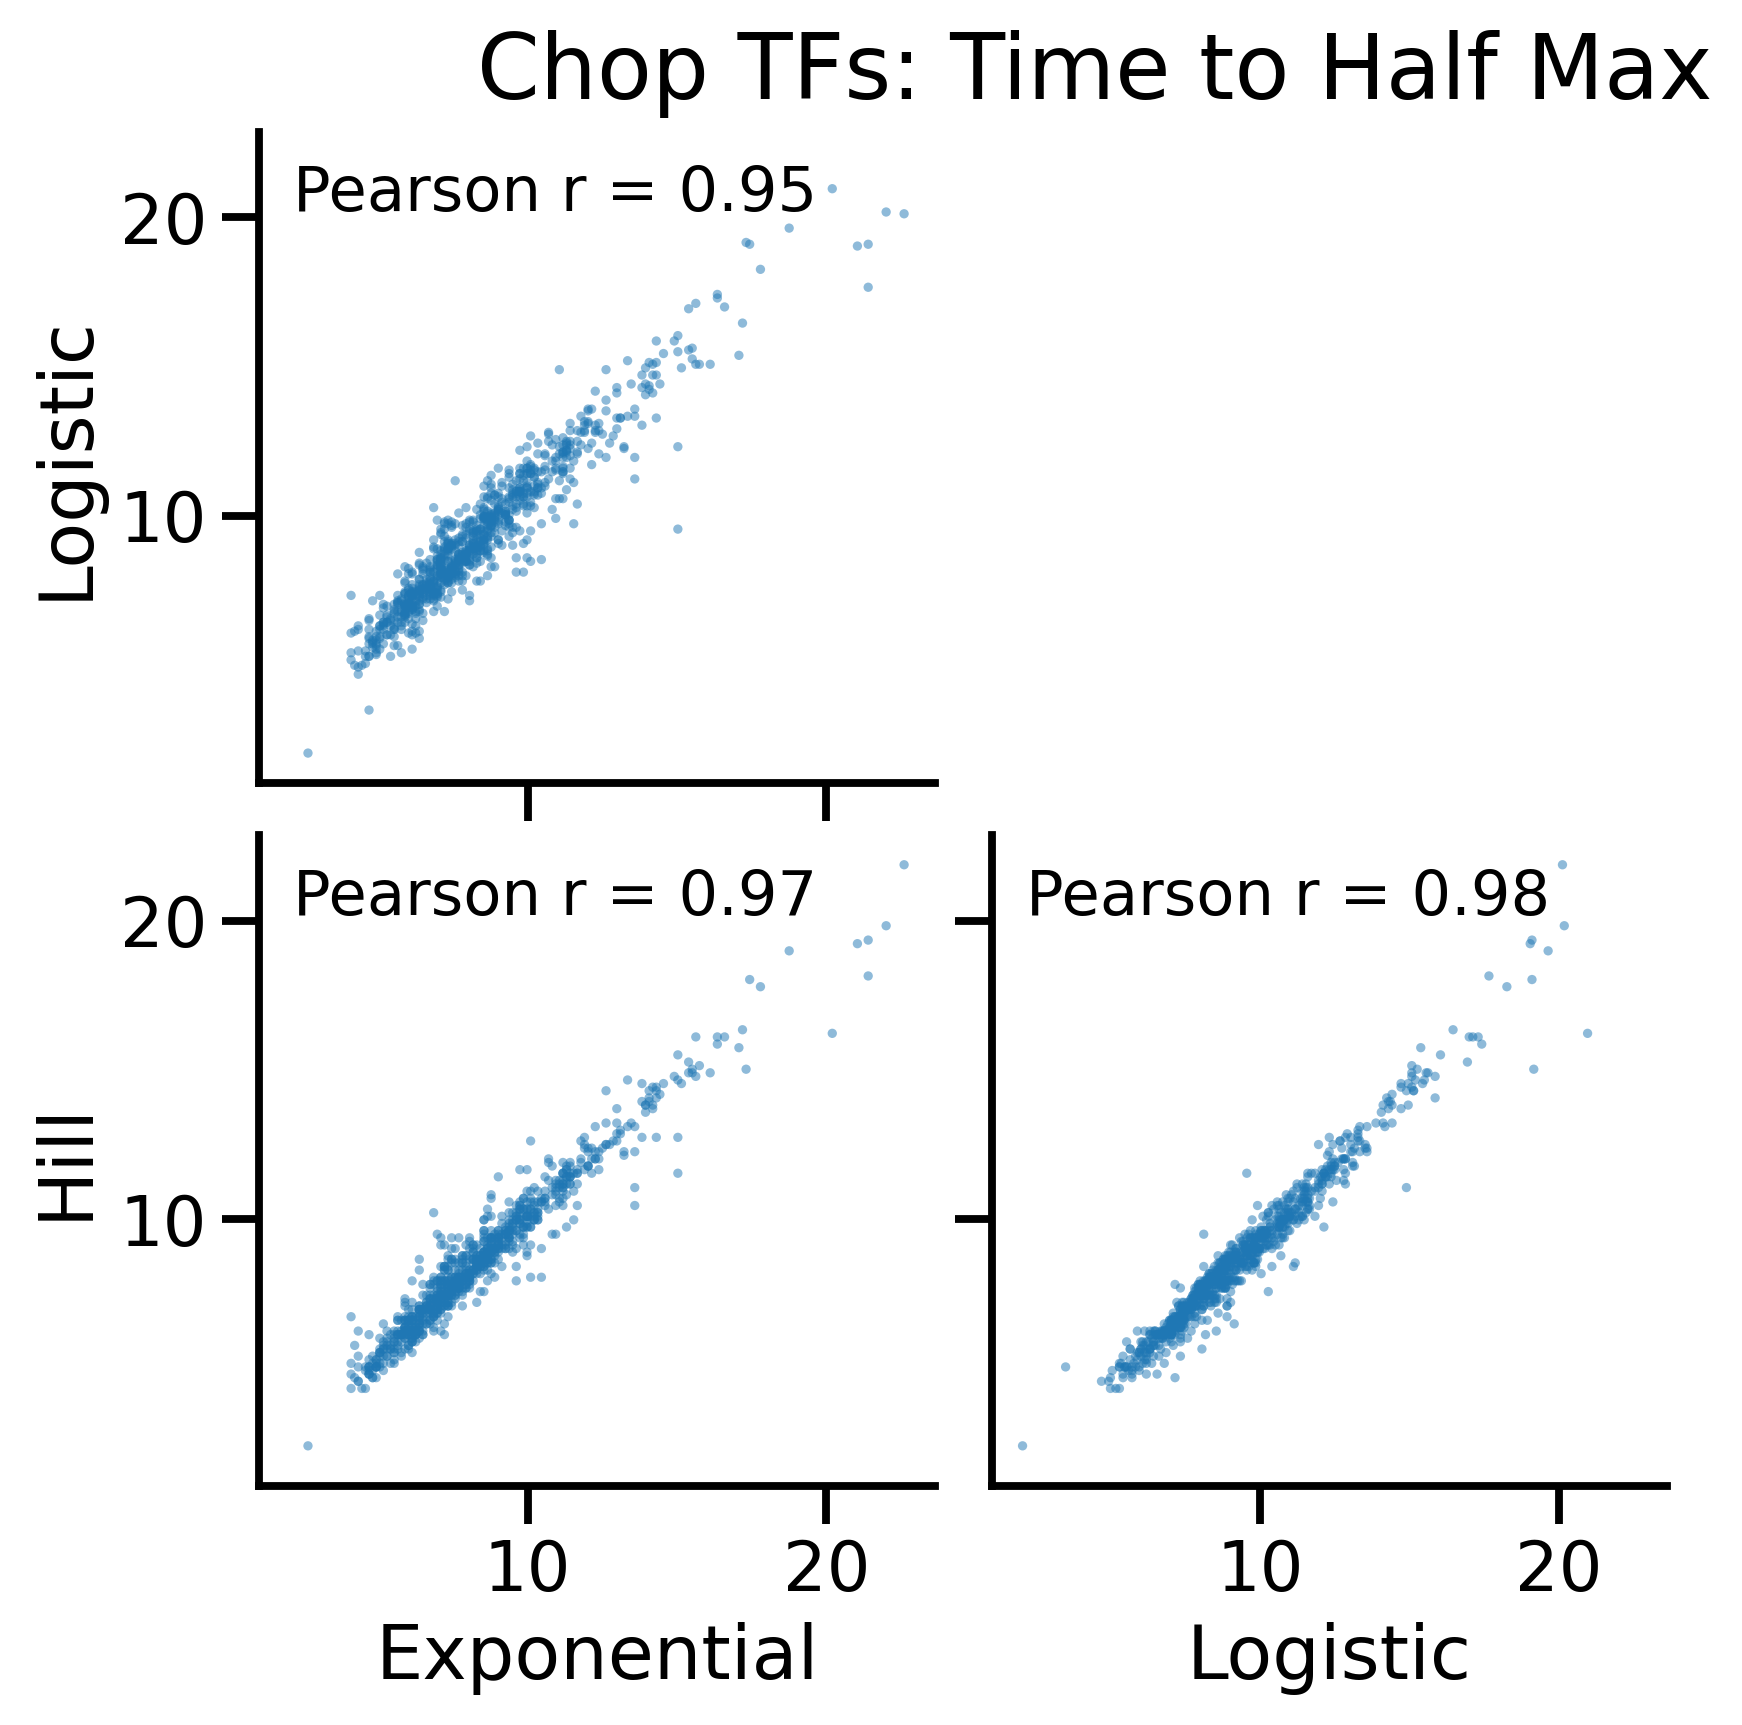

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_context('talk')

cols = ["t_half_exp", "t_half_log", "t_half_hill", ]
df = merged[cols].dropna()
df.columns = ["Exponential", "Logistic", "Hill"]
cols = df.columns.tolist()  # <-- sync cols to new names

fig, axes = plt.subplots(3, 3, figsize=(8, 8), sharex=True, sharey=True, dpi  =300)

for i, y_var in enumerate(cols):
    for j, x_var in enumerate(cols):
        ax = axes[i, j]
        if j >= i:
            ax.set_visible(False)
            continue

        sns.scatterplot(data=df, x=x_var, y=y_var, ax=ax, alpha=0.5, s=5, edgecolor="none")

        r, p = stats.pearsonr(df[x_var], df[y_var])
        ax.annotate(f"Pearson r = {r:.2f}", xy=(0.05, 0.95), xycoords="axes fraction",
                    ha="left", va="top", fontsize='small')

        if j == 0:
            ax.set_ylabel(y_var)
        if i == len(cols) - 1:
            ax.set_xlabel(x_var)

plt.suptitle("Chop TFs: Time to Half Max", y = 0.7, x = 0.45)
sns.despine()
plt.tight_layout(pad = 0.2)
plt.show()

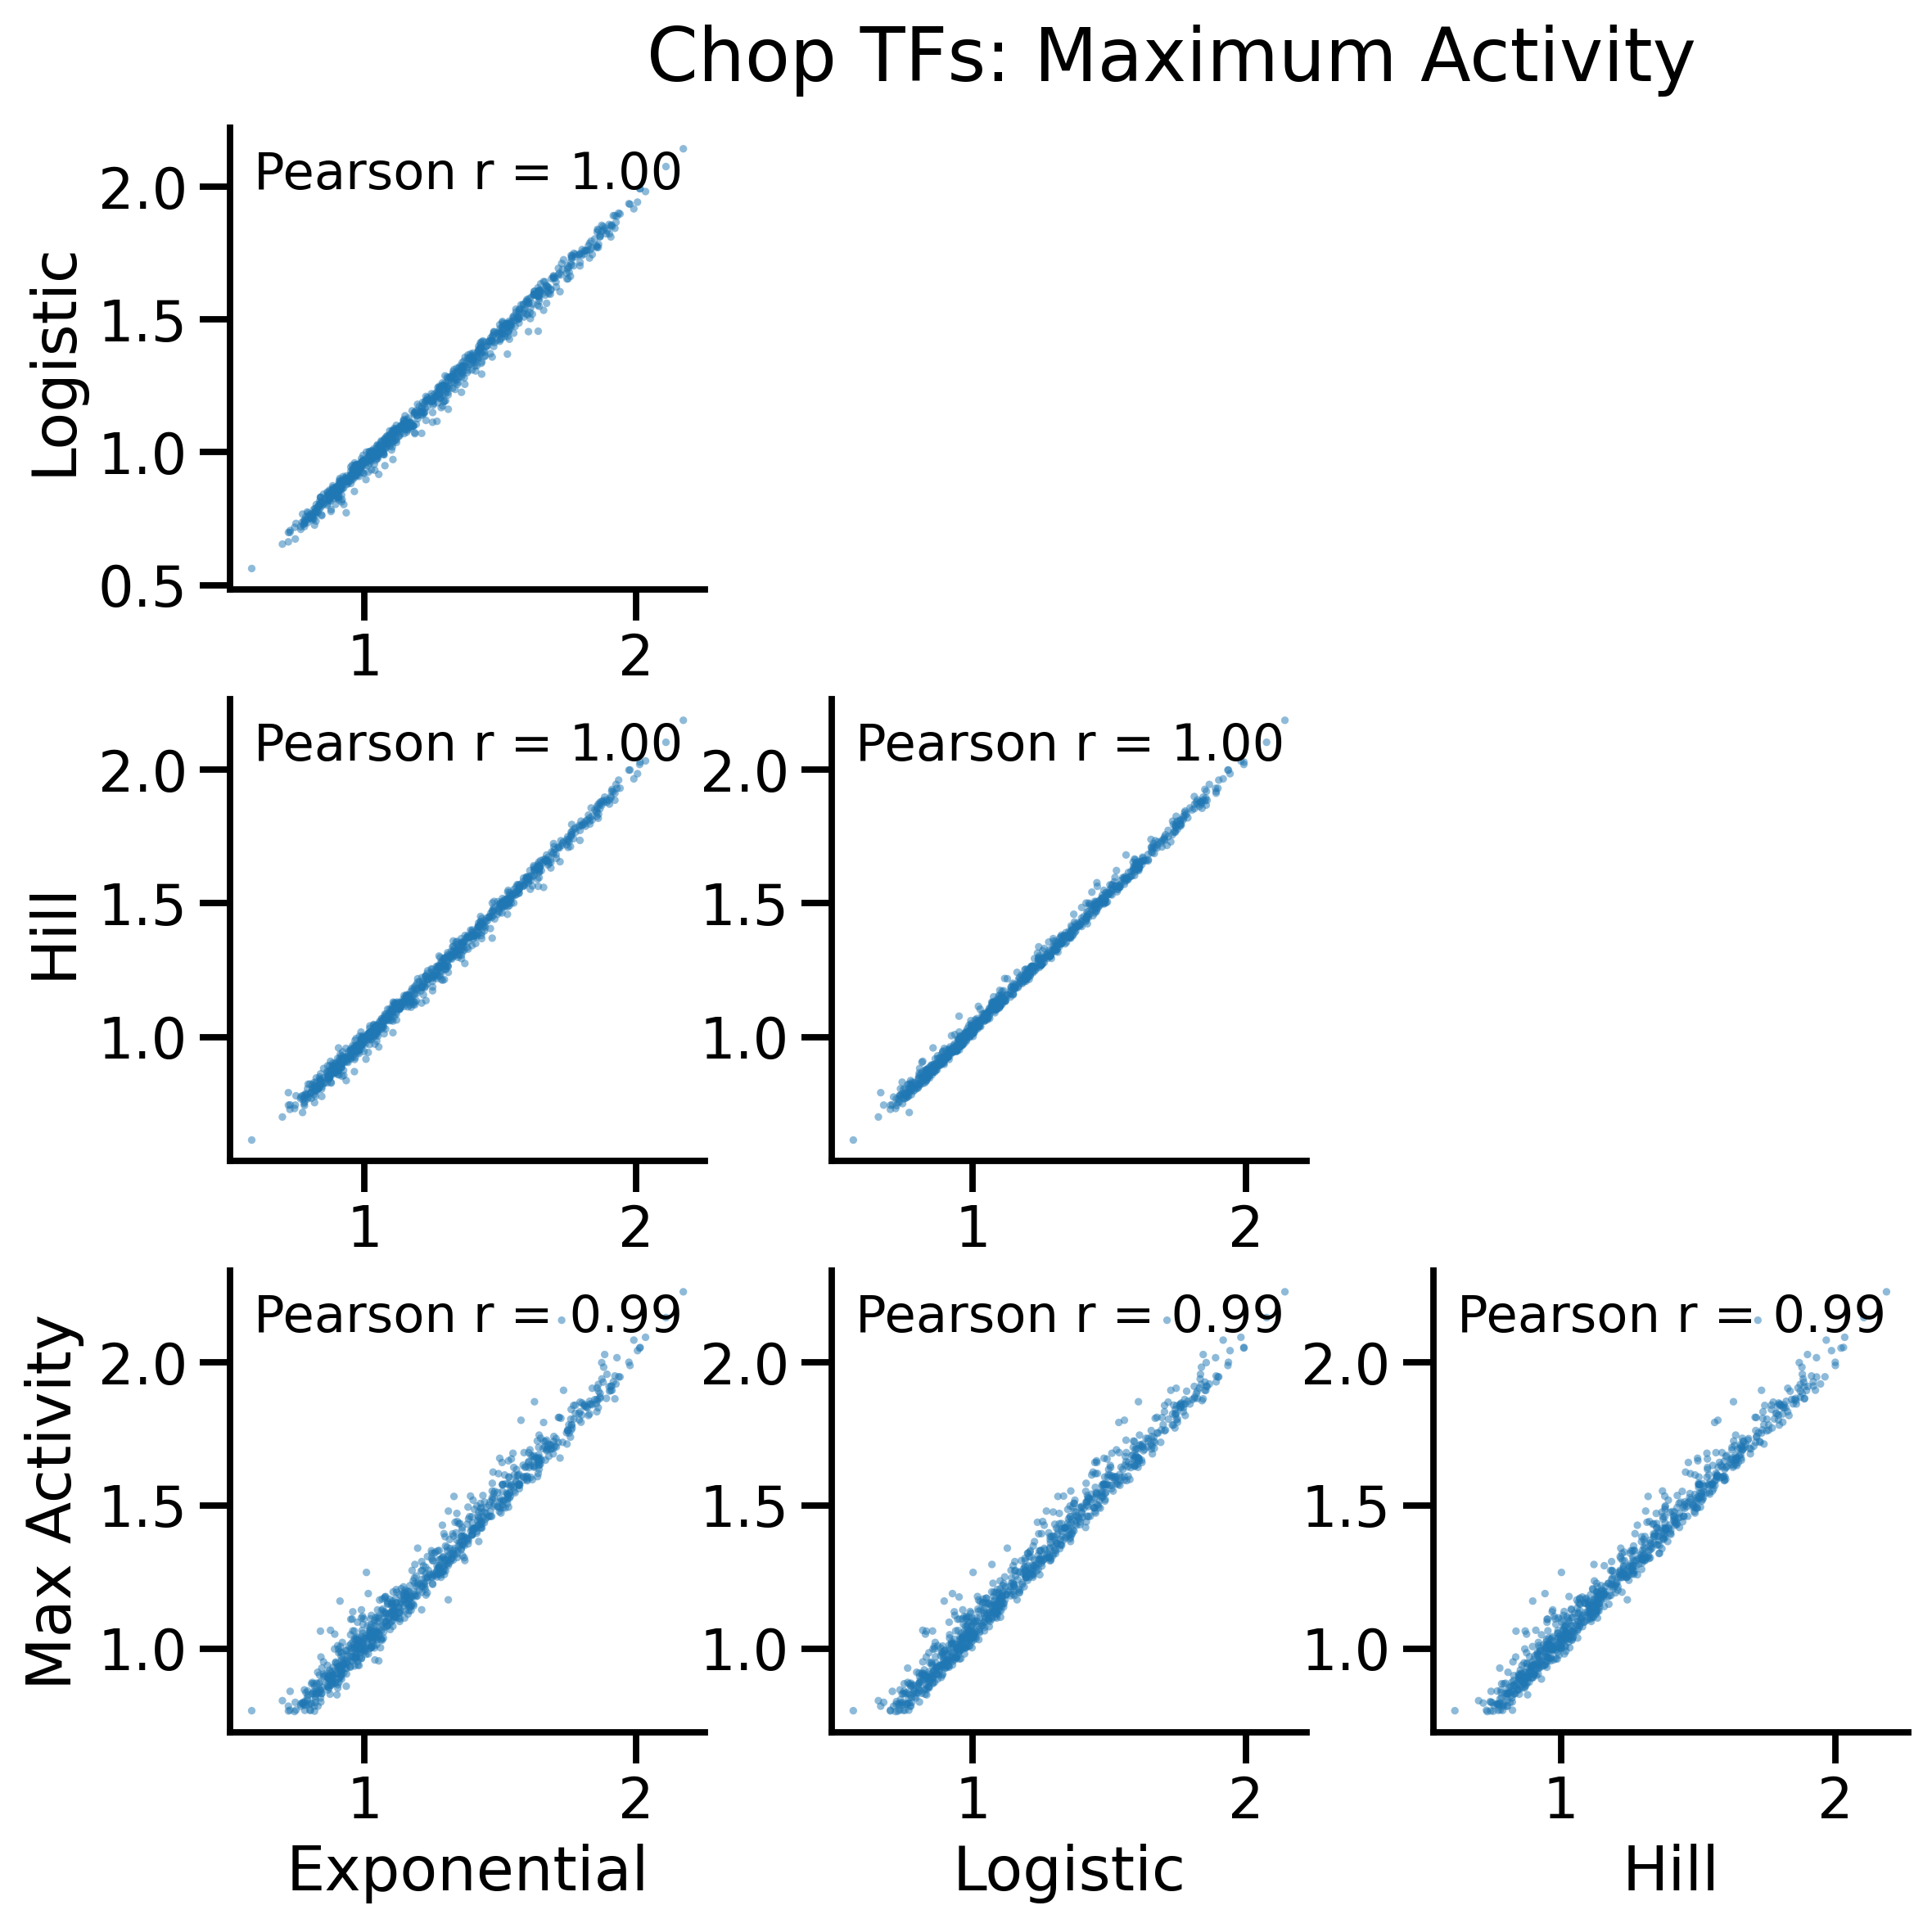

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_context('talk')

cols = ["obs_max_exp", "obs_max_log", "obs_max_hill", "max_activity"]
df = merged[cols].dropna()
df.columns = ["Exponential", "Logistic", "Hill", "Max Activity"]
cols = df.columns.tolist()

fig, axes = plt.subplots(4, 4, figsize=(10, 10), sharex=False, sharey=False, dpi = 300)

for i, y_var in enumerate(cols):
    for j, x_var in enumerate(cols):
        ax = axes[i, j]
        if j >= i:
            ax.set_visible(False)
            continue

        sns.scatterplot(data=df, x=x_var, y=y_var, ax=ax, alpha=0.5, s=5, edgecolor="none")

        r, p = stats.pearsonr(df[x_var], df[y_var])
        ax.annotate(f"Pearson r = {r:.2f}", xy=(0.05, 0.95), xycoords="axes fraction",
                    ha="left", va="top", fontsize='small')

        if j == 0:
            ax.set_ylabel(y_var)
        else:
            ax.set_ylabel("")
        if i == len(cols) - 1:
            ax.set_xlabel(x_var)
        else:
            ax.set_xlabel("")

plt.suptitle("Chop TFs: Maximum Activity", y=0.77, x=0.45)
sns.despine()
plt.tight_layout(pad=0.2)
plt.show()

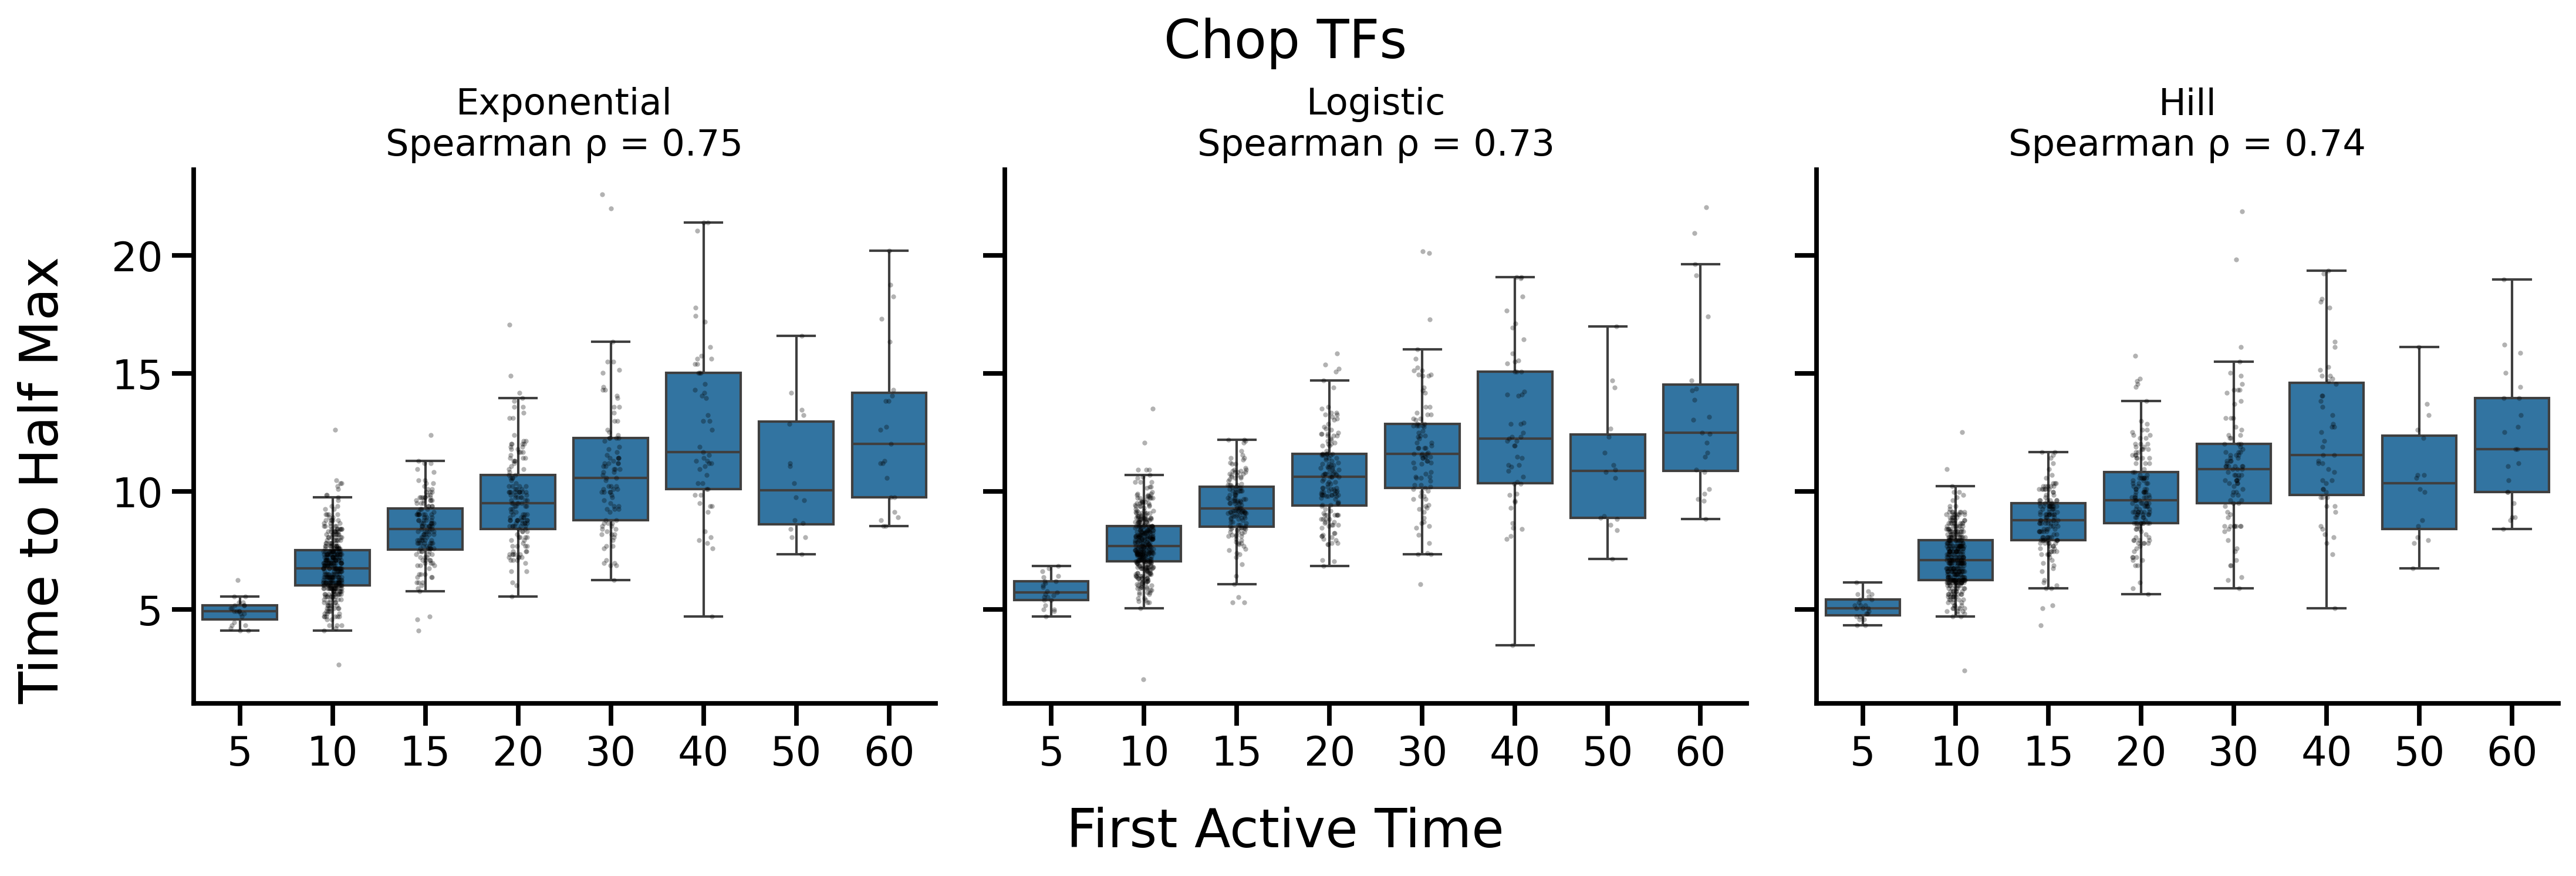

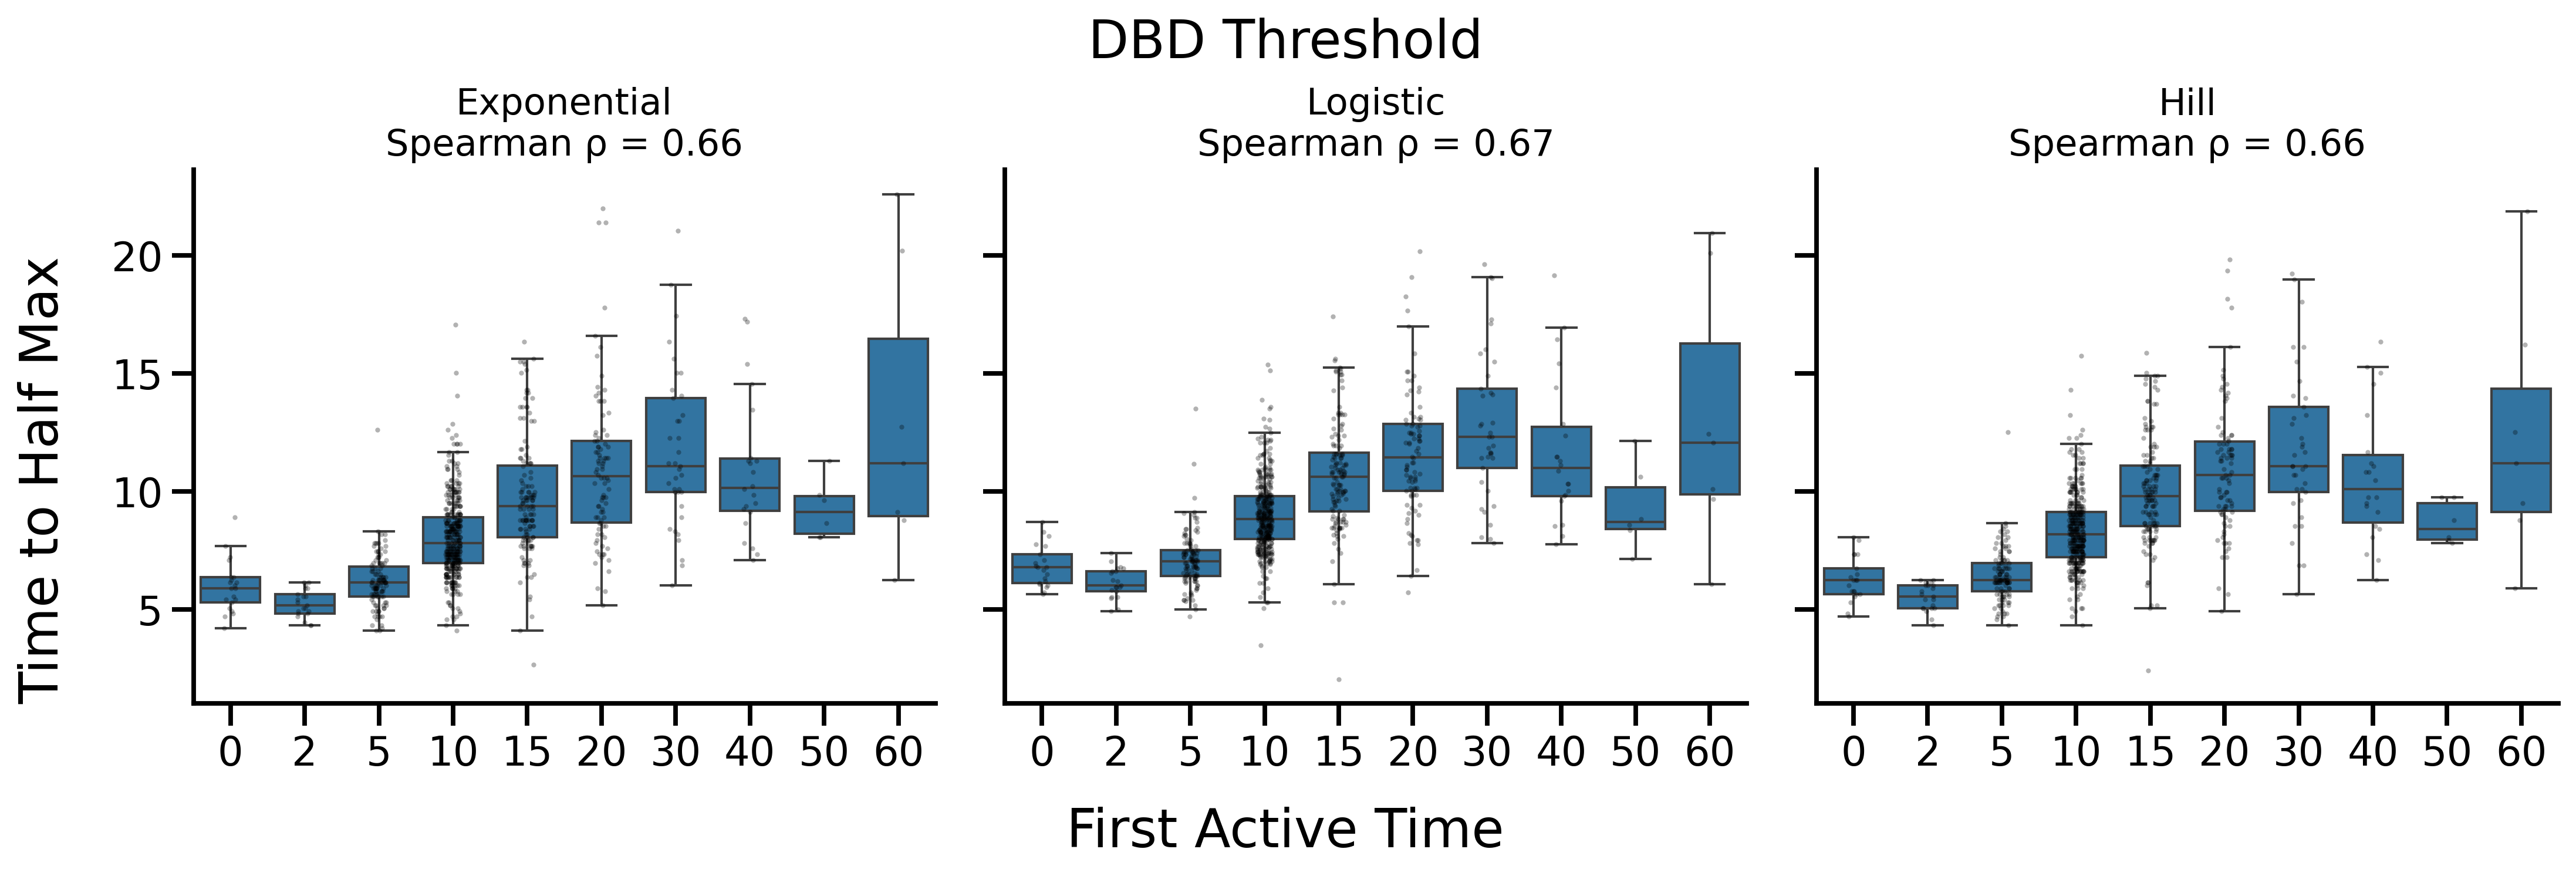

In [12]:
models = [
    ("t_half_exp", "Exponential"),
    ("t_half_log", "Logistic"),
    ("t_half_hill", "Hill"),
]

for col_time, title in zip(
    ["first_pass_time", "first_pass_time_DBD"],
    ["Chop TFs", "DBD Threshold"]
):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, dpi=300)
    df = merged.copy()

    df = df.dropna(subset=[col_time])
    df[col_time] = df[col_time].astype(int)

    for ax, (col, subplot_title) in zip(axes, models):
        sns.boxplot(
            x=df[col_time], 
            y=df[col], 
            ax=ax,
            color="C0",
            fliersize=0
        )
        sns.stripplot(
            x=df[col_time], 
            y=df[col], 
            ax=ax,
            color="black",
            alpha=0.3,
            size=2
        )

        # correlation
        from scipy.stats import spearmanr
        subdf = df[[col_time, col]].dropna()
        r, p = spearmanr(subdf[col_time], subdf[col])

        ax.set_title(f"{subplot_title}\nSpearman ρ = {r:.2f}", fontsize='small')

        ax.set_xlabel("")
        ax.set_ylabel("")

    fig.supxlabel("First Active Time", y=0.07)
    fig.supylabel("Time to Half Max")

    sns.despine()
    plt.tight_layout()
    plt.suptitle(title, y=1.025)
    plt.show()

# Summary

In [13]:
merged

,ADseq,t_half_exp,obs_max_exp,t_half_log,obs_max_log,t_half_hill,obs_max_hill,first_pass_time,max_activity,max_activity_DBD,first_pass_time_DBD
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,2.645291,1.150497,2.042042,1.137649,2.404810,1.149031,10,1.204614,0.801983,15.0
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,5.651303,1.551581,6.606607,1.513870,5.771543,1.551690,10,1.550627,1.970491,2.0
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,6.132265,1.391873,7.267267,1.370633,6.372745,1.399850,10,1.411124,1.285137,10.0
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,8.296593,0.973756,8.828829,0.921619,8.416834,0.947896,20,1.014475,1.191691,10.0
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,6.492986,1.406179,7.387387,1.347826,6.853707,1.379290,10,1.486441,1.624554,10.0
...,...,...,...,...,...,...,...,...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,8.296593,1.426466,9.549550,1.390677,8.777555,1.415576,10,1.453678,1.376673,10.0
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,9.979960,0.982423,10.930931,0.942420,10.100200,0.970270,20,0.996907,1.136863,15.0
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,6.973948,1.471982,8.288288,1.436320,7.334669,1.473238,10,1.520583,1.463755,10.0
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,9.018036,1.143447,10.210210,1.107947,9.619238,1.140620,15,1.192689,1.288224,10.0


In [14]:
import numpy as np
import pandas as pd

models = ["exp", "log", "hill"]

# --- keep only full rows ---
cols_needed = [f"{p}_{m}" for m in models for p in ["t_half", "obs_max"]]
filtered = merged.dropna(subset=cols_needed).copy()

# --- aggregate ---
filtered["mean_t_half"] = filtered[[f"t_half_{m}" for m in models]].mean(axis=1)
filtered["mean_max"] = filtered[[f"obs_max_{m}" for m in models]].mean(axis=1)


# ===============================
# helper: pick 3 representative points
# ===============================
def pick_three(df, sort_col):
    df = df.sort_values(sort_col).reset_index(drop=True)
    n = len(df)

    if n < 3:
        return df  # fallback

    return pd.concat([
        df.iloc[[0]],
        df.iloc[[n // 2]],
        df.iloc[[-1]]
    ])


# ===============================
# 1. SAME strength, DIFFERENT speed
# ===============================
A_target = filtered["mean_max"].median()
A_tol = filtered["mean_max"].std() * 0.2

similar_A = filtered[
    (filtered["mean_max"] >= A_target - A_tol) &
    (filtered["mean_max"] <= A_target + A_tol)
].copy()

seq_simA_diffk = pick_three(similar_A, "mean_t_half")


# ===============================
# 2. SAME speed, DIFFERENT strength
# ===============================
k_target = filtered["mean_t_half"].median()
k_tol = filtered["mean_t_half"].std() * 0.2

similar_k = filtered[
    (filtered["mean_t_half"] >= k_target - k_tol) &
    (filtered["mean_t_half"] <= k_target + k_tol)
].copy()

seq_simk_diffA = pick_three(similar_k, "mean_max")


# --- combine ---
selected = pd.concat([seq_simA_diffk, seq_simk_diffA]).drop_duplicates("ADseq")
selected_adseqs = selected["ADseq"].tolist()
selected_adseqs

['AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN',
 'LSNDMEVGWSDLTKLTVPLDKDLSLGTAMSLYSSIFDRLF',
 'DFYQIKDRVLVKEVYNPEDLYHLRILNSLTACYLEYSISY',
 'QVVHQGIGSHTEDSSLGSHSGGYDFFNELLDKKADTLHNE',
 'LGDVYLSSSDIAELFQEFATKYHQFLPVVDLSKGAERIYH',
 'DNSNNGDGNNNNTISELVCFDESIADLYPVEIDSPYLITL']

In [29]:
from scipy.stats import pearsonr, spearmanr

def plot_all_model_speed_strength(selected_adseqs = None):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True, dpi=300)
    title_dict = {"exp": "Exponential", "log": "Logistic", "hill": "Hill"}
    
    for ax, model in zip(axs, ["exp", "log", "hill"]):
        ax.set_title(title_dict[model])
        sns.scatterplot(data=merged, x=f"t_half_{model}", y=f"obs_max_{model}",
                        ax=ax, alpha=0.7, edgecolor='none', s=15)
    
        xy = merged[[f"t_half_{model}", f"obs_max_{model}"]].dropna()
        r, _ = pearsonr(xy.iloc[:, 0], xy.iloc[:, 1])
        rho, _ = spearmanr(xy.iloc[:, 0], xy.iloc[:, 1])
        ax.annotate(f"Spearman r = {r:.2f}\nPearson ρ = {rho:.2f}", xy=(0.95, 0.95),
                    xycoords="axes fraction", fontsize='small', ha='right', va='top', color = 'goldenrod')

        if selected_adseqs:
            for ad in selected_adseqs:
                row = merged[merged["ADseq"] == ad]
                
                x = row[f"t_half_{model}"].values[0]
                y = row[f"obs_max_{model}"].values[0]
        
                ax.scatter(
                    x, y,
                    color='red',
                    s=160,
                    marker="*",
                    edgecolor="red",
                    linewidth=0.7,
                    zorder=10
                )
    
        ax.set_xlabel("")
        ax.set_ylabel("")
    
    plt.tight_layout()
    fig.supxlabel("Time to Half Max", y=-0.03)
    fig.supylabel("Observed\nModeled Max", x=-0.02, ha='center')
    fig.suptitle("Chop TFs", y=1.05)
    sns.despine()

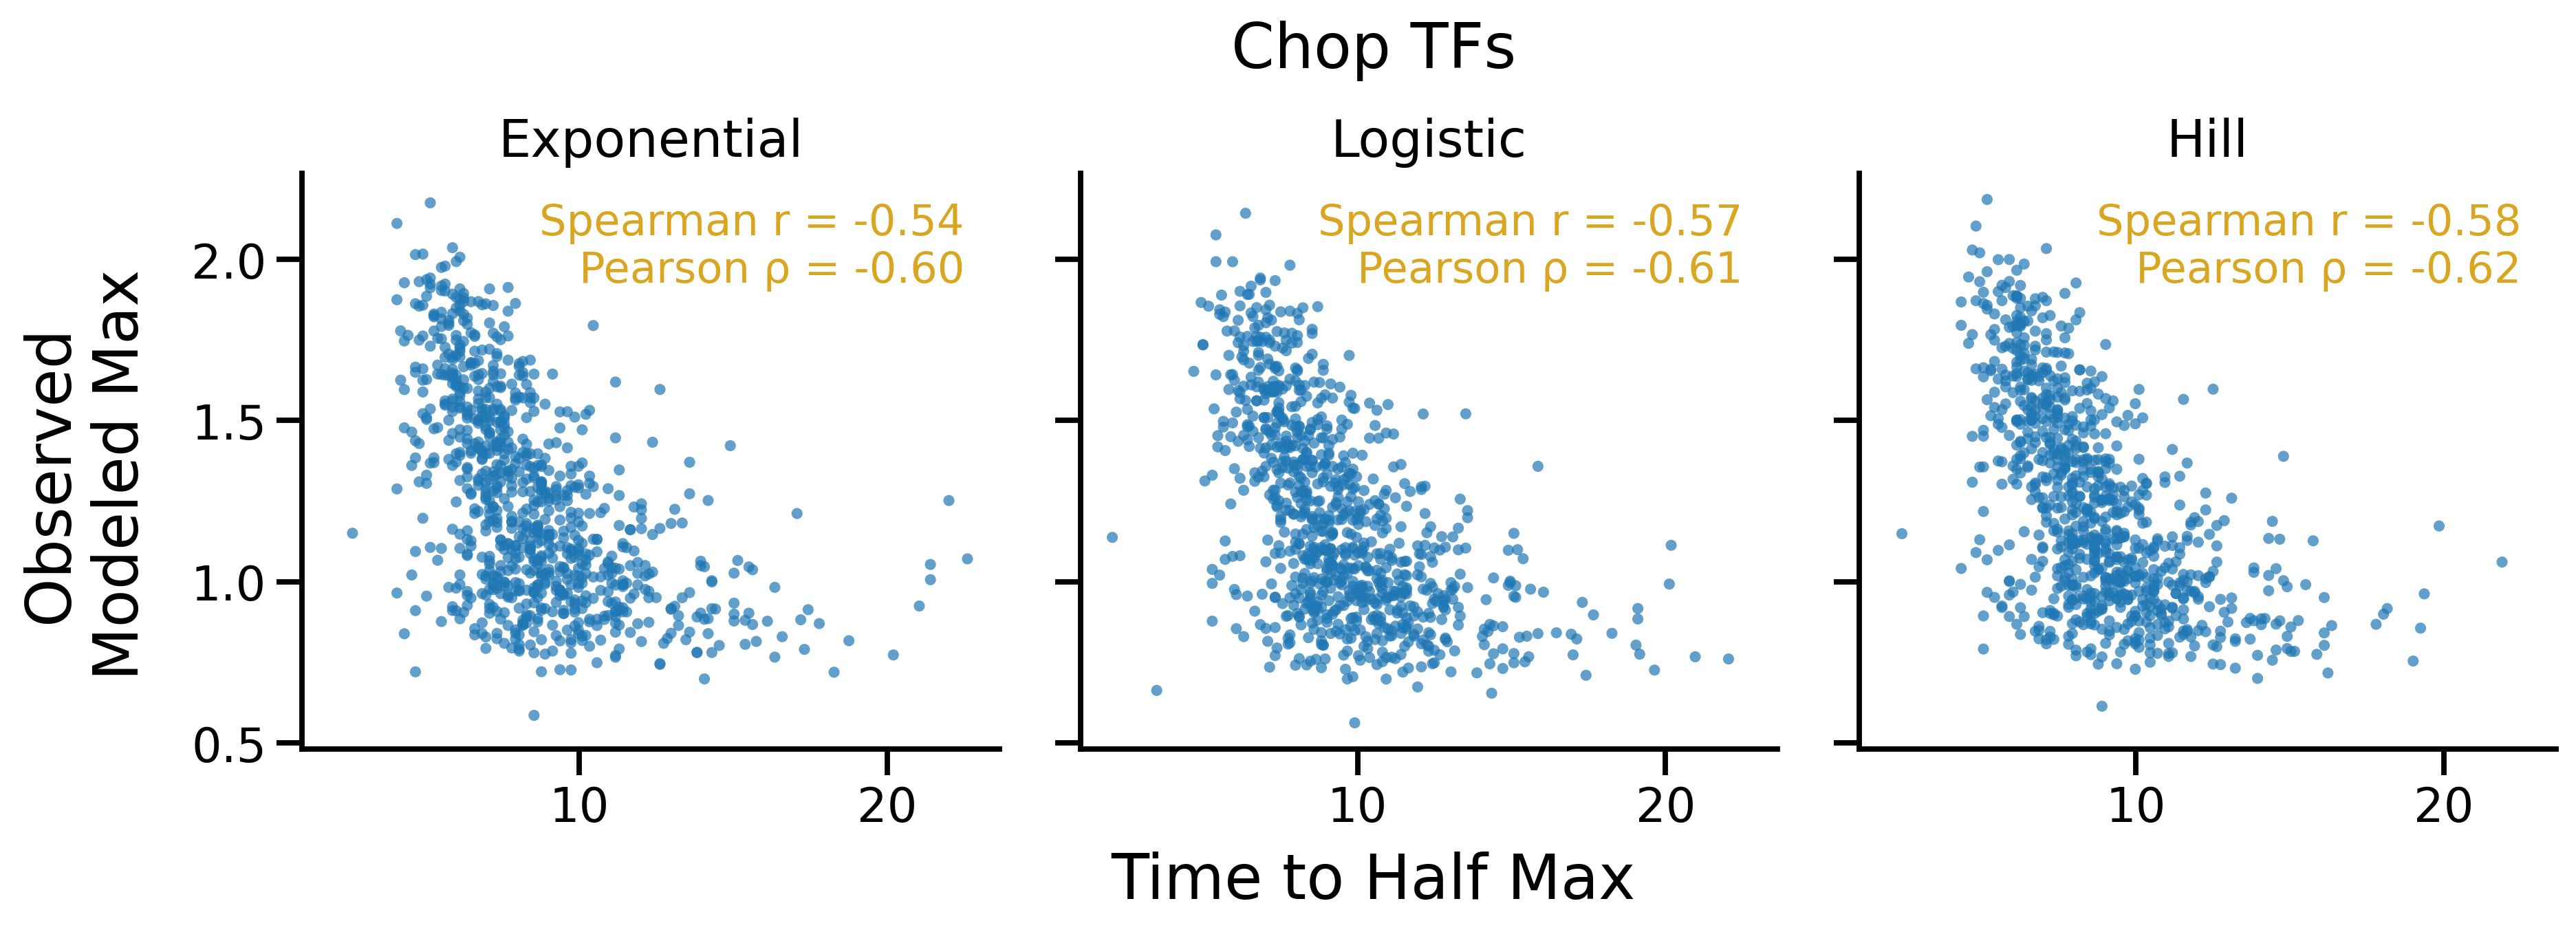

In [30]:
plot_all_model_speed_strength()

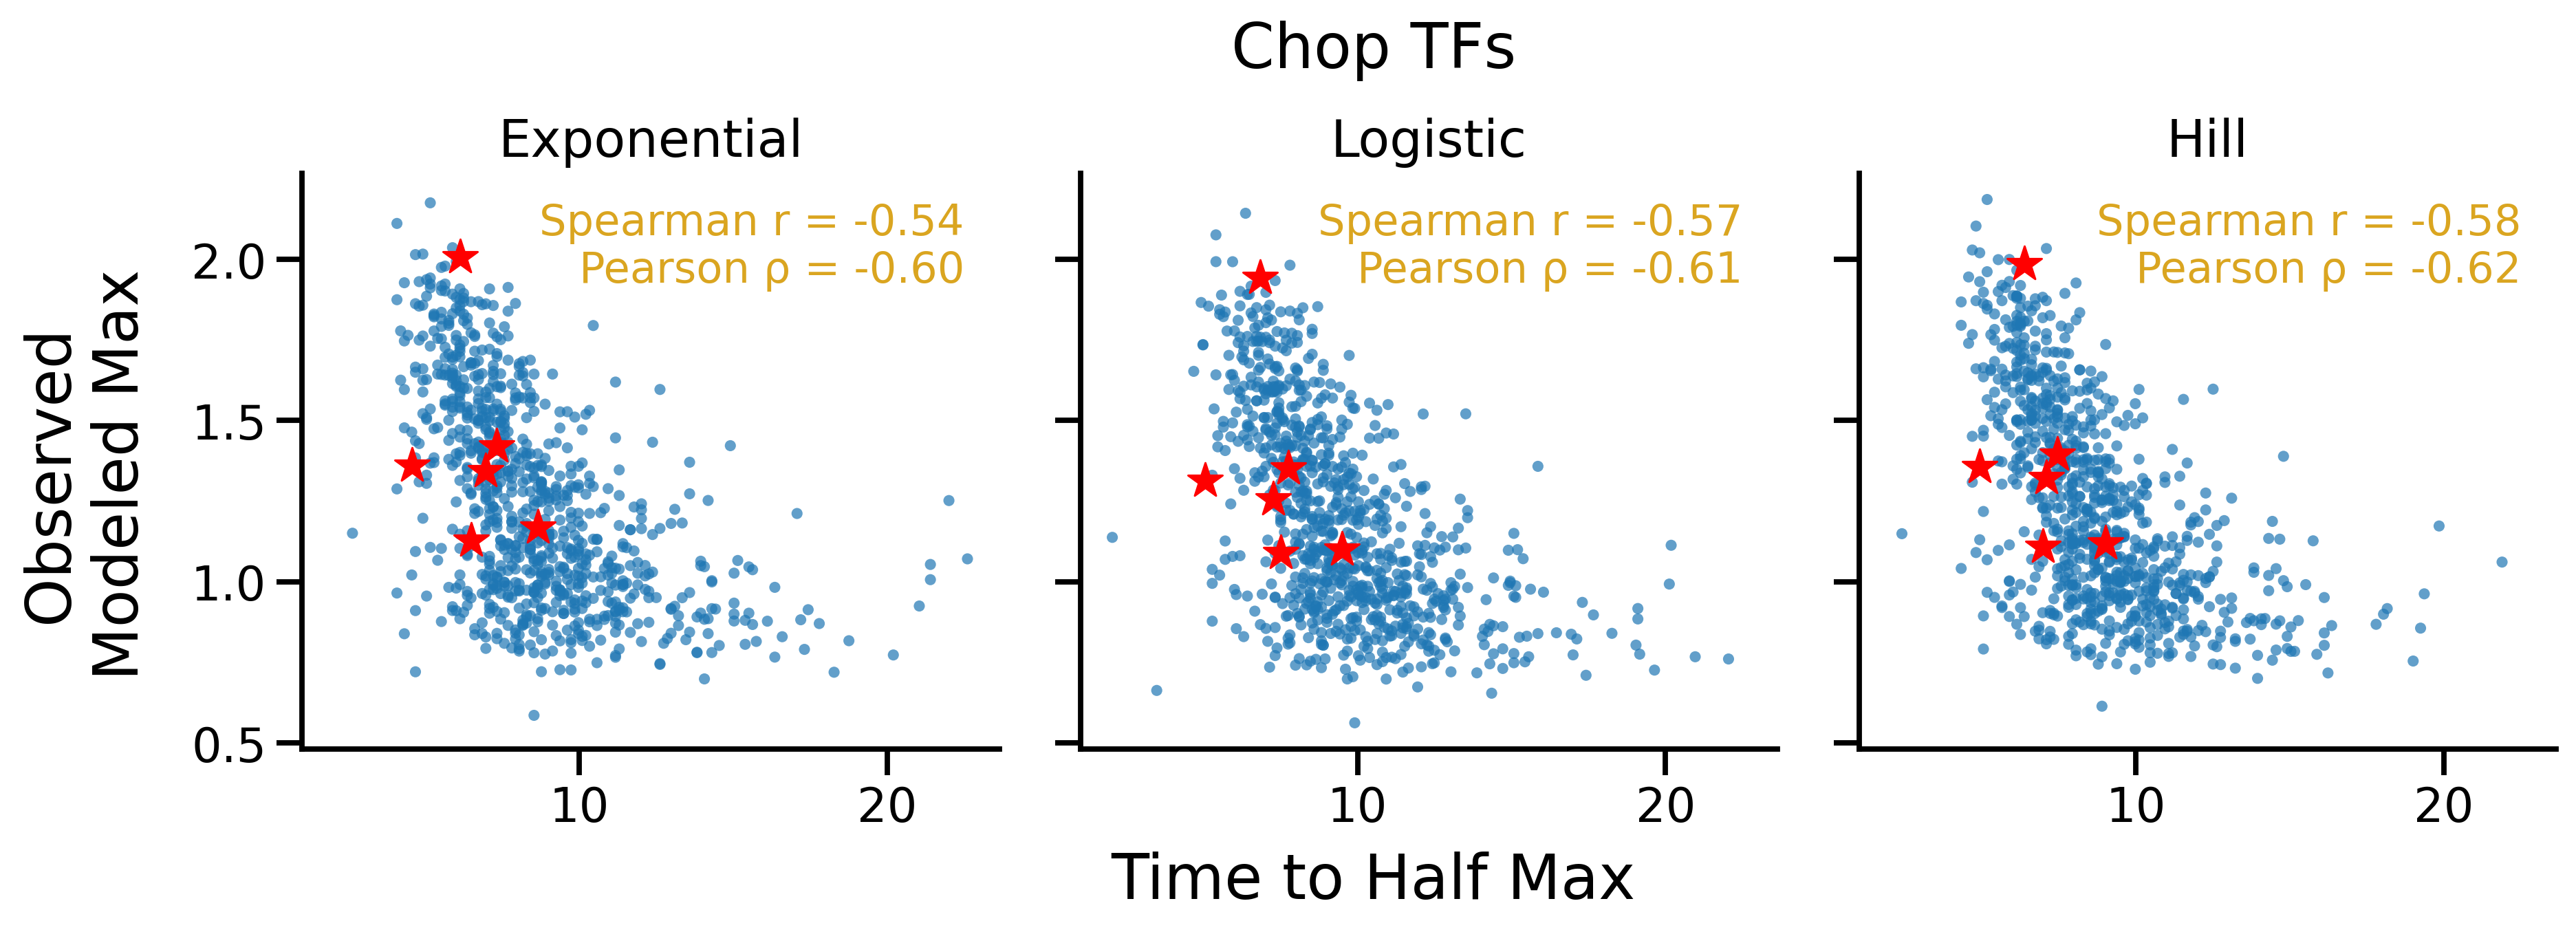

In [31]:
plot_all_model_speed_strength(selected_adseqs)

In [18]:
activities = pd.read_csv("../../../output/ChopTFs_pipeline/speed/activities_to_fit.csv", index_col = 0)
activities['mean'] = activities["activity"]
activities

,ADseq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error,activity_norm,ci_low_norm,ci_hi_norm,mean
142,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0,-0.402631,-0.569555,-0.165864,ns,NaN,NaN,0.102982,0.000000,-0.166925,0.236767,-0.402631
143,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,2,0.067719,-0.086268,0.196101,ns,0.470349,0.009113,0.072033,0.470349,0.316362,0.598732,0.067719
144,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,10,0.423909,0.019486,0.796737,activator,0.826539,0.001168,0.198278,0.826539,0.422117,1.199367,0.423909
145,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,15,0.786642,0.691610,0.871152,activator,1.189273,0.000881,0.045801,1.189273,1.094241,1.273783,0.786642
146,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,20,0.567249,0.388742,0.736468,activator,0.969880,0.000730,0.088706,0.969880,0.791373,1.139099,0.567249
...,...,...,...,...,...,...,...,...,...,...,...,...,...
118600,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,20,1.560700,1.399946,1.635293,activator,1.430020,0.000730,0.060037,1.430020,1.269266,1.504612,1.560700
118601,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,30,1.707046,1.668821,1.736109,activator,1.576366,0.000621,0.017165,1.576366,1.538140,1.605428,1.707046
118602,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,40,1.721909,1.702173,1.740391,activator,1.591228,0.000550,0.009749,1.591228,1.571493,1.609710,1.721909
118603,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,50,1.650853,1.592250,1.699947,activator,1.520173,0.000548,0.027474,1.520173,1.461570,1.569266,1.650853


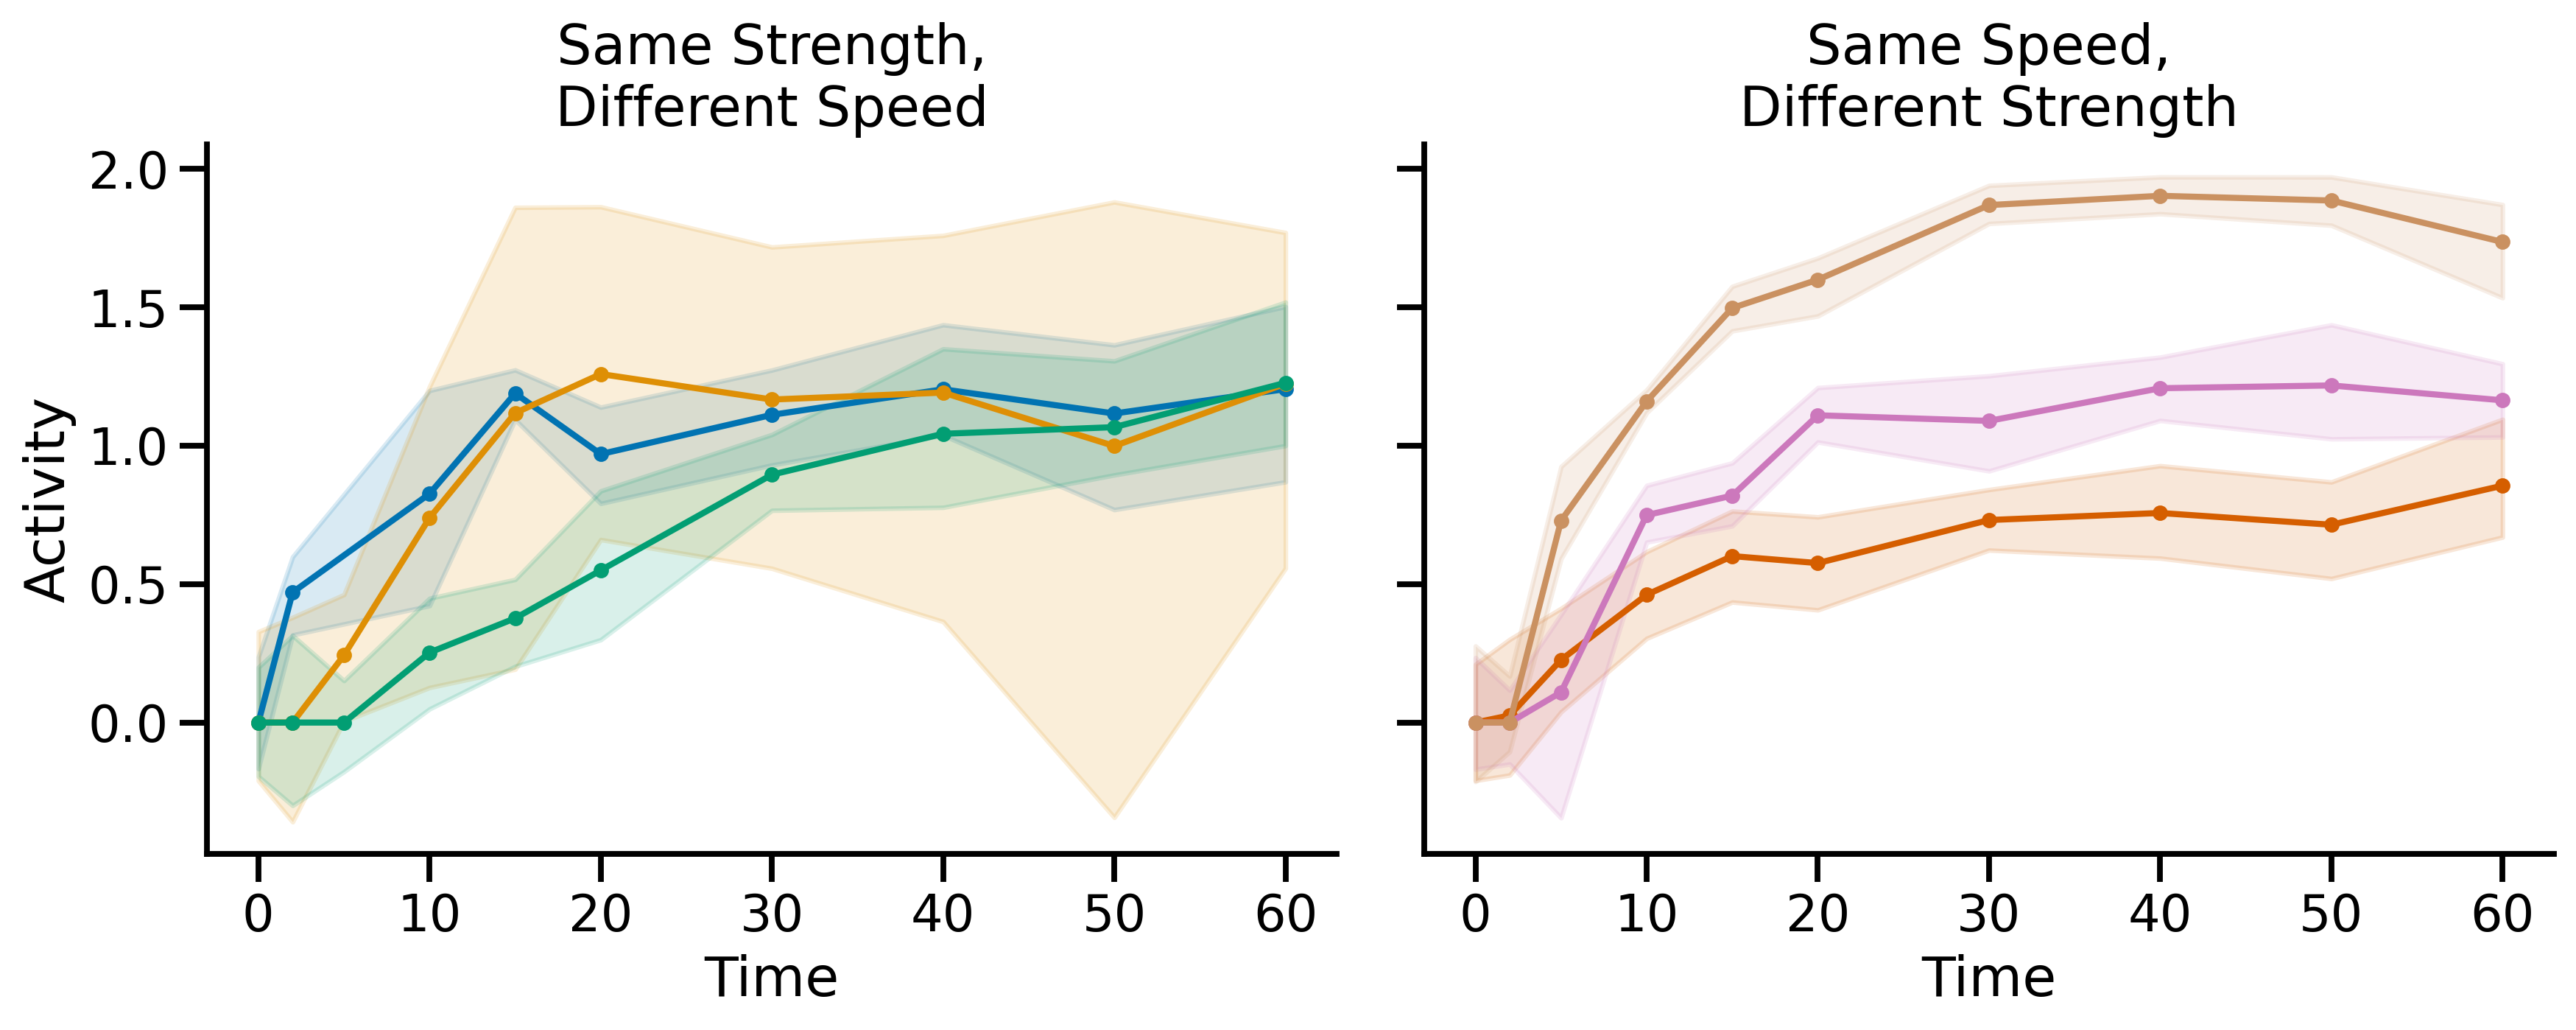

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

df = activities  # trajectory df

plot_df = df[df["ADseq"].isin(selected_adseqs)].copy()
plot_df = plot_df.sort_values(["ADseq", "time"])

# stable colors
colors = dict(zip(selected_adseqs, sns.color_palette("colorblind", n_colors=len(selected_adseqs))))

# --- enforce grouping explicitly (IMPORTANT) ---
group_speed = selected_adseqs[:3]   # same strength, different speed
group_strength = selected_adseqs[3:]  # same speed, different strength

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, dpi=300)

panels = [
    (axs[0], group_speed, "Same Strength,\nDifferent Speed"),
    (axs[1], group_strength, "Same Speed,\nDifferent Strength"),
]

for ax, group, title in panels:

    for ad in group:
        g = plot_df[plot_df["ADseq"] == ad].sort_values("time")

        t = g["time"].values
        y = g["activity_norm"].values
        lo = g["ci_low_norm"].values
        hi = g["ci_hi_norm"].values

        c = colors[ad]

        # CI band
        ax.fill_between(t, lo, hi, color=c, alpha=0.15)

        # trajectory
        ax.plot(
            t, y,
            color=c,
            linewidth=2,
            marker="o",
            markersize=4,
            label=ad[:6]
        )

    ax.set_title(title)
    ax.set_xlabel("Time")

# shared y-axis
axs[0].set_ylabel("Activity")

# styling
for ax in axs:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# Controls for max

In [20]:
chopTF_controls = pd.read_csv("../../../data/chopTFs_controls.csv", index_col = 0)
controls_to_keep = ["vp16N_0", "VP16C_0", "GCN4_CAAD40_0", "GAL4_AD1_0", "War1_Cterm_0"]
chopTF_controls_to_keep = chopTF_controls[chopTF_controls["Name"].isin(controls_to_keep)]
chopTF_controls_to_keep

,ADseq,Name,group
11,STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK,GCN4_CAAD40_0,GCN4_CAAD
4,STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF,GAL4_AD1_0,Gal4
37,DSPGPGFTPHDSAPYGALDMADFEFEQMFTDALGIDEYGG,VP16C_0,VP16C
35,STAPPTDVSLGDELHLDGEDVAMAHADALDDFDLDMLGDG,vp16N_0,VP16N
19,PSPSSSVDNLNDYLTDINSLAWGVNSLNDEFWTDLFMNDI,War1_Cterm_0,War1


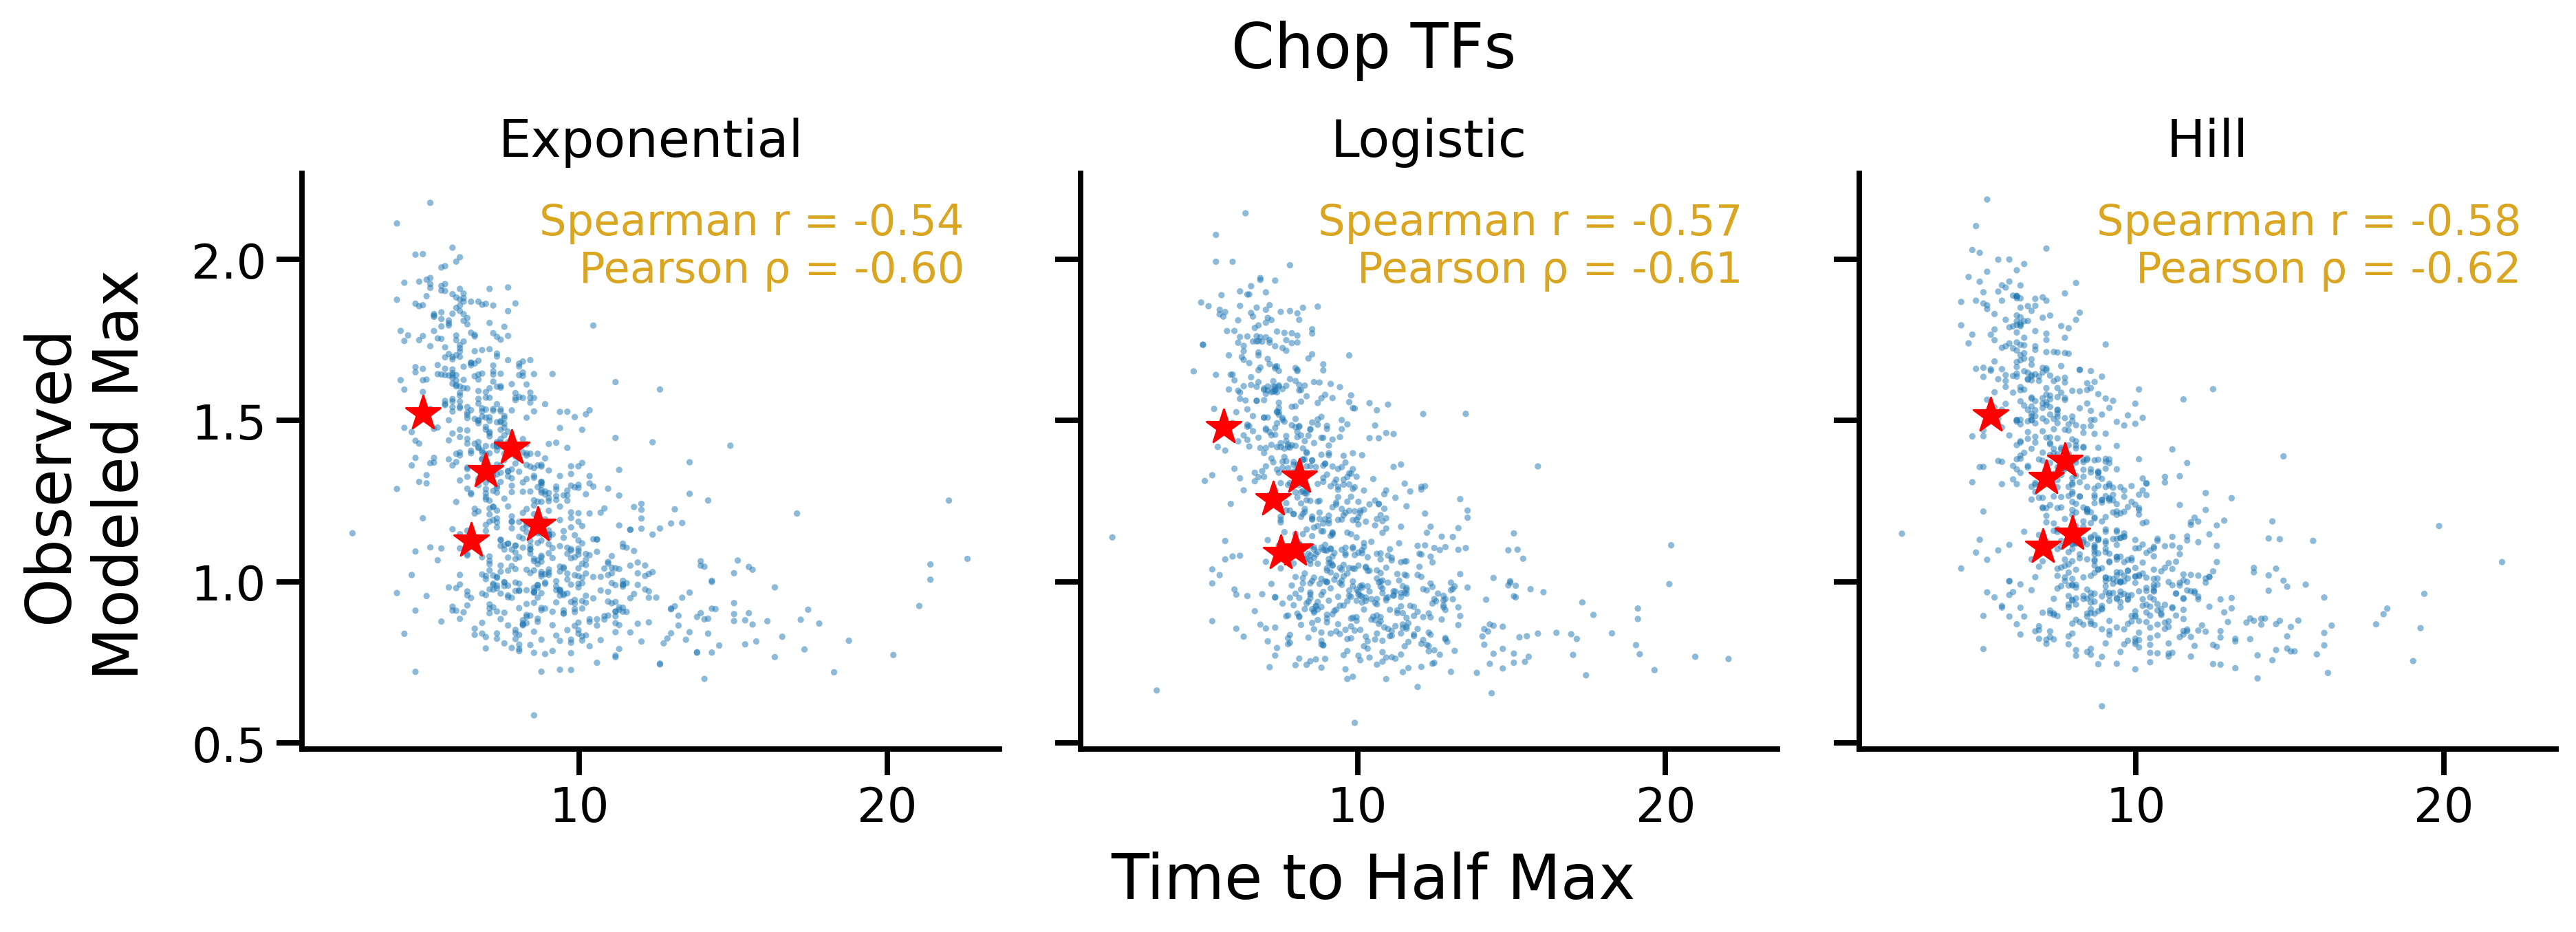

In [21]:
plot_all_model_speed_strength(list(chopTF_controls_to_keep["ADseq"]))

Text(0.5, 1.0, 'ChopTFs')

<Figure size 1920x1440 with 0 Axes>

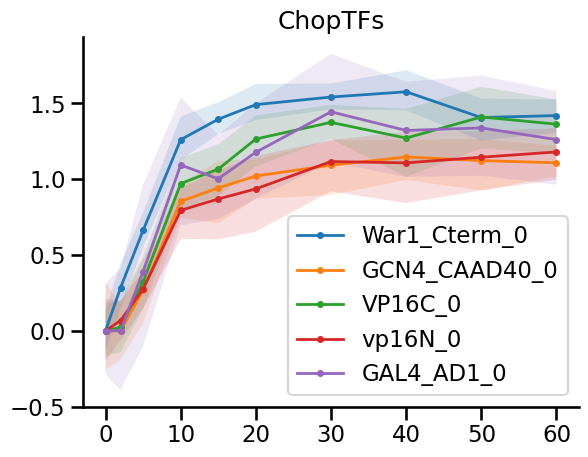

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(dpi = 300)
df = activities  # trajectory df

control_ADseqs = list(chopTF_controls_to_keep["ADseq"])

plot_df = df[df["ADseq"].isin(control_ADseqs)].copy()
plot_df = plot_df.sort_values(["ADseq", "time"])
colors = dict(zip(control_ADseqs, sns.color_palette("colorblind", n_colors=len(selected_adseqs))))

fig,ax = plt.subplots()

for AD in set(control_ADseqs):
    g = plot_df[plot_df["ADseq"] == AD].sort_values("time")
    
    t = g["time"].values
    y = g["activity_norm"].values
    lo = g["ci_low_norm"].values
    hi = g["ci_hi_norm"].values
    ax.plot(
        t, y,
        linewidth=2,
        marker="o",
        markersize=4,
        label=dict(zip(chopTF_controls_to_keep["ADseq"], chopTF_controls_to_keep["Name"]))[AD]
    )
    ax.fill_between(t, lo, hi, alpha=0.15)

plt.legend()
sns.despine()
plt.title("ChopTFs")

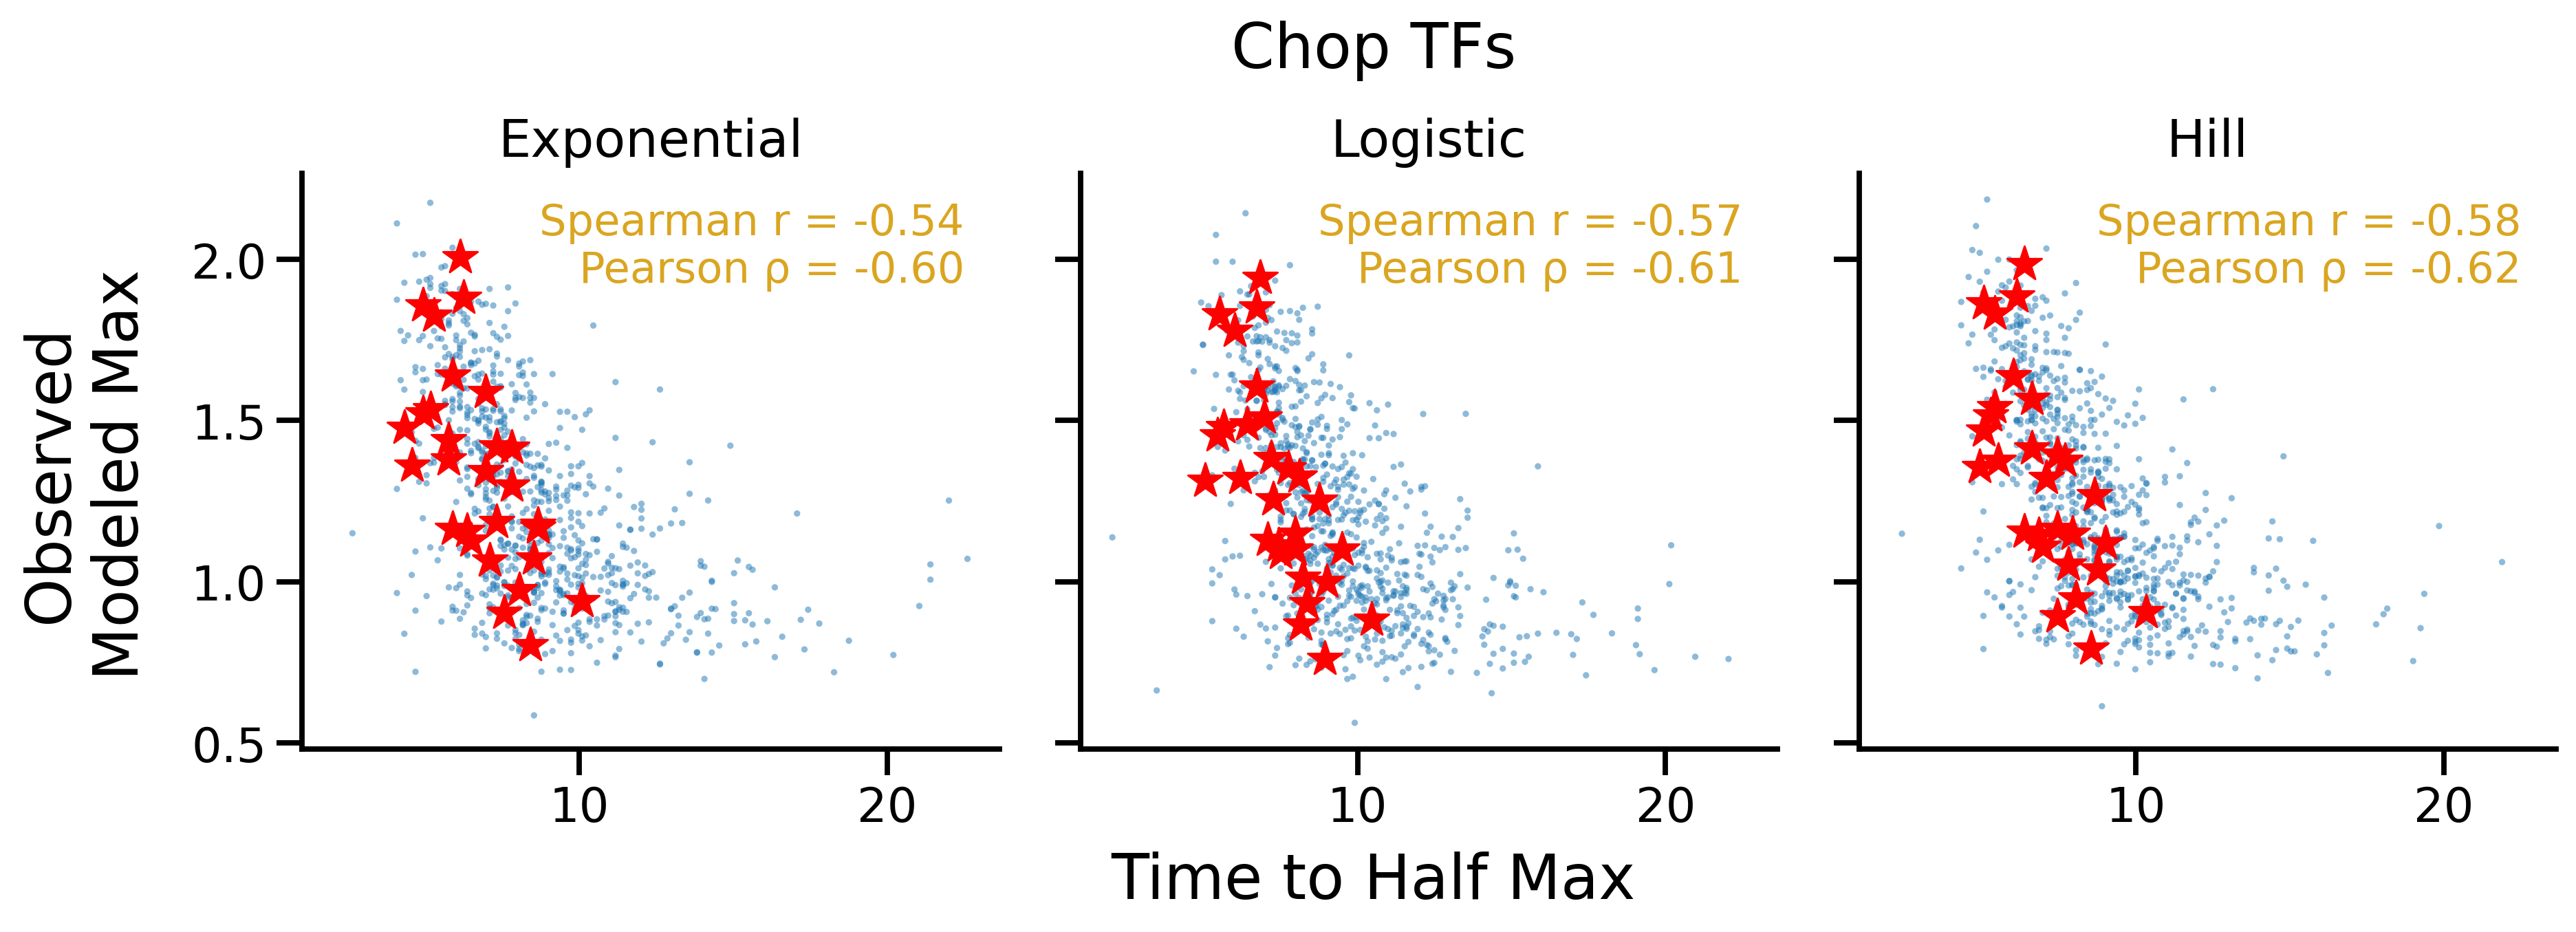

In [23]:
# All controls have similar strengths
plot_all_model_speed_strength(set(list(chopTF_controls[chopTF_controls["ADseq"].isin(merged["ADseq"])]["ADseq"])))

In [24]:
import numpy as np
import pandas as pd

models = ["exp", "log", "hill"]

# --- keep only full rows ---
cols_needed = [f"{p}_{m}" for m in models for p in ["t_half", "obs_max"]]
filtered = merged[merged["ADseq"].isin(chopTF_controls["ADseq"])].dropna(subset=cols_needed).copy()

# --- aggregate ---
filtered["mean_t_half"] = filtered[[f"t_half_{m}" for m in models]].mean(axis=1)
filtered["mean_max"]    = filtered[[f"obs_max_{m}" for m in models]].mean(axis=1)

# ===============================
# helper: pick 3 representative points (low / mid / high)
# ===============================
def pick_three(df, sort_col):
    df = df.sort_values(sort_col).reset_index(drop=True)
    n = len(df)
    if n < 3:
        return df
    return pd.concat([df.iloc[[0]], df.iloc[[n // 2]], df.iloc[[-1]]])

# ===============================
# 1. FIXED speed → 3 different strengths
#    Pick the median t_half row, then find 3 seqs with
#    similar t_half but spread-out mean_max values.
# ===============================
median_t_half = filtered["mean_t_half"].median()
fixed_speed_anchor = (filtered["mean_t_half"] - median_t_half).abs().idxmin()
fixed_speed = filtered.loc[fixed_speed_anchor, "mean_t_half"]

# tolerance: within 20 % of the full t_half range around that fixed speed
t_half_range = filtered["mean_t_half"].max() - filtered["mean_t_half"].min()
speed_tol = t_half_range * 0.15

similar_speed = filtered[
    (filtered["mean_t_half"] >= fixed_speed - speed_tol) &
    (filtered["mean_t_half"] <= fixed_speed + speed_tol)
].copy()

seq_fixedSpeed_diffStrength = pick_three(similar_speed, "mean_max")

# ===============================
# 2. FIXED strength → 3 different speeds
#    Pick the median mean_max row, then find 3 seqs with
#    similar mean_max but spread-out t_half values.
# ===============================
median_max = filtered["mean_max"].median()
fixed_strength_anchor = (filtered["mean_max"] - median_max).abs().idxmin()
fixed_strength = filtered.loc[fixed_strength_anchor, "mean_max"]

# tolerance: within 20 % of the full mean_max range around that fixed strength
max_range = filtered["mean_max"].max() - filtered["mean_max"].min()
strength_tol = max_range * 0.15

similar_strength = filtered[
    (filtered["mean_max"] >= fixed_strength - strength_tol) &
    (filtered["mean_max"] <= fixed_strength + strength_tol)
].copy()

seq_fixedStrength_diffSpeed = pick_three(similar_strength, "mean_t_half")

# --- combine ---
selected = pd.concat([seq_fixedSpeed_diffStrength, seq_fixedStrength_diffSpeed]).drop_duplicates("ADseq")
selected_adseqs = selected["ADseq"].tolist()
selected_adseqs

['STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADK',
 'TDAIDEEVLMSLVIEMGLDRIKELPELALGQNEADAMTDA',
 'TDFIDEEVLMSLVIEMGLDRIKELPELWLGQNEFDFMTDF',
 'STDSTPMFEYEGLEDNSKEWTSLFDNDIPVTTDDVSPADK',
 'STIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPNNNGF',
 'STDSTPMFDYDNLEDNSKDWTSLFDNDIPVTTDDVSLADK']

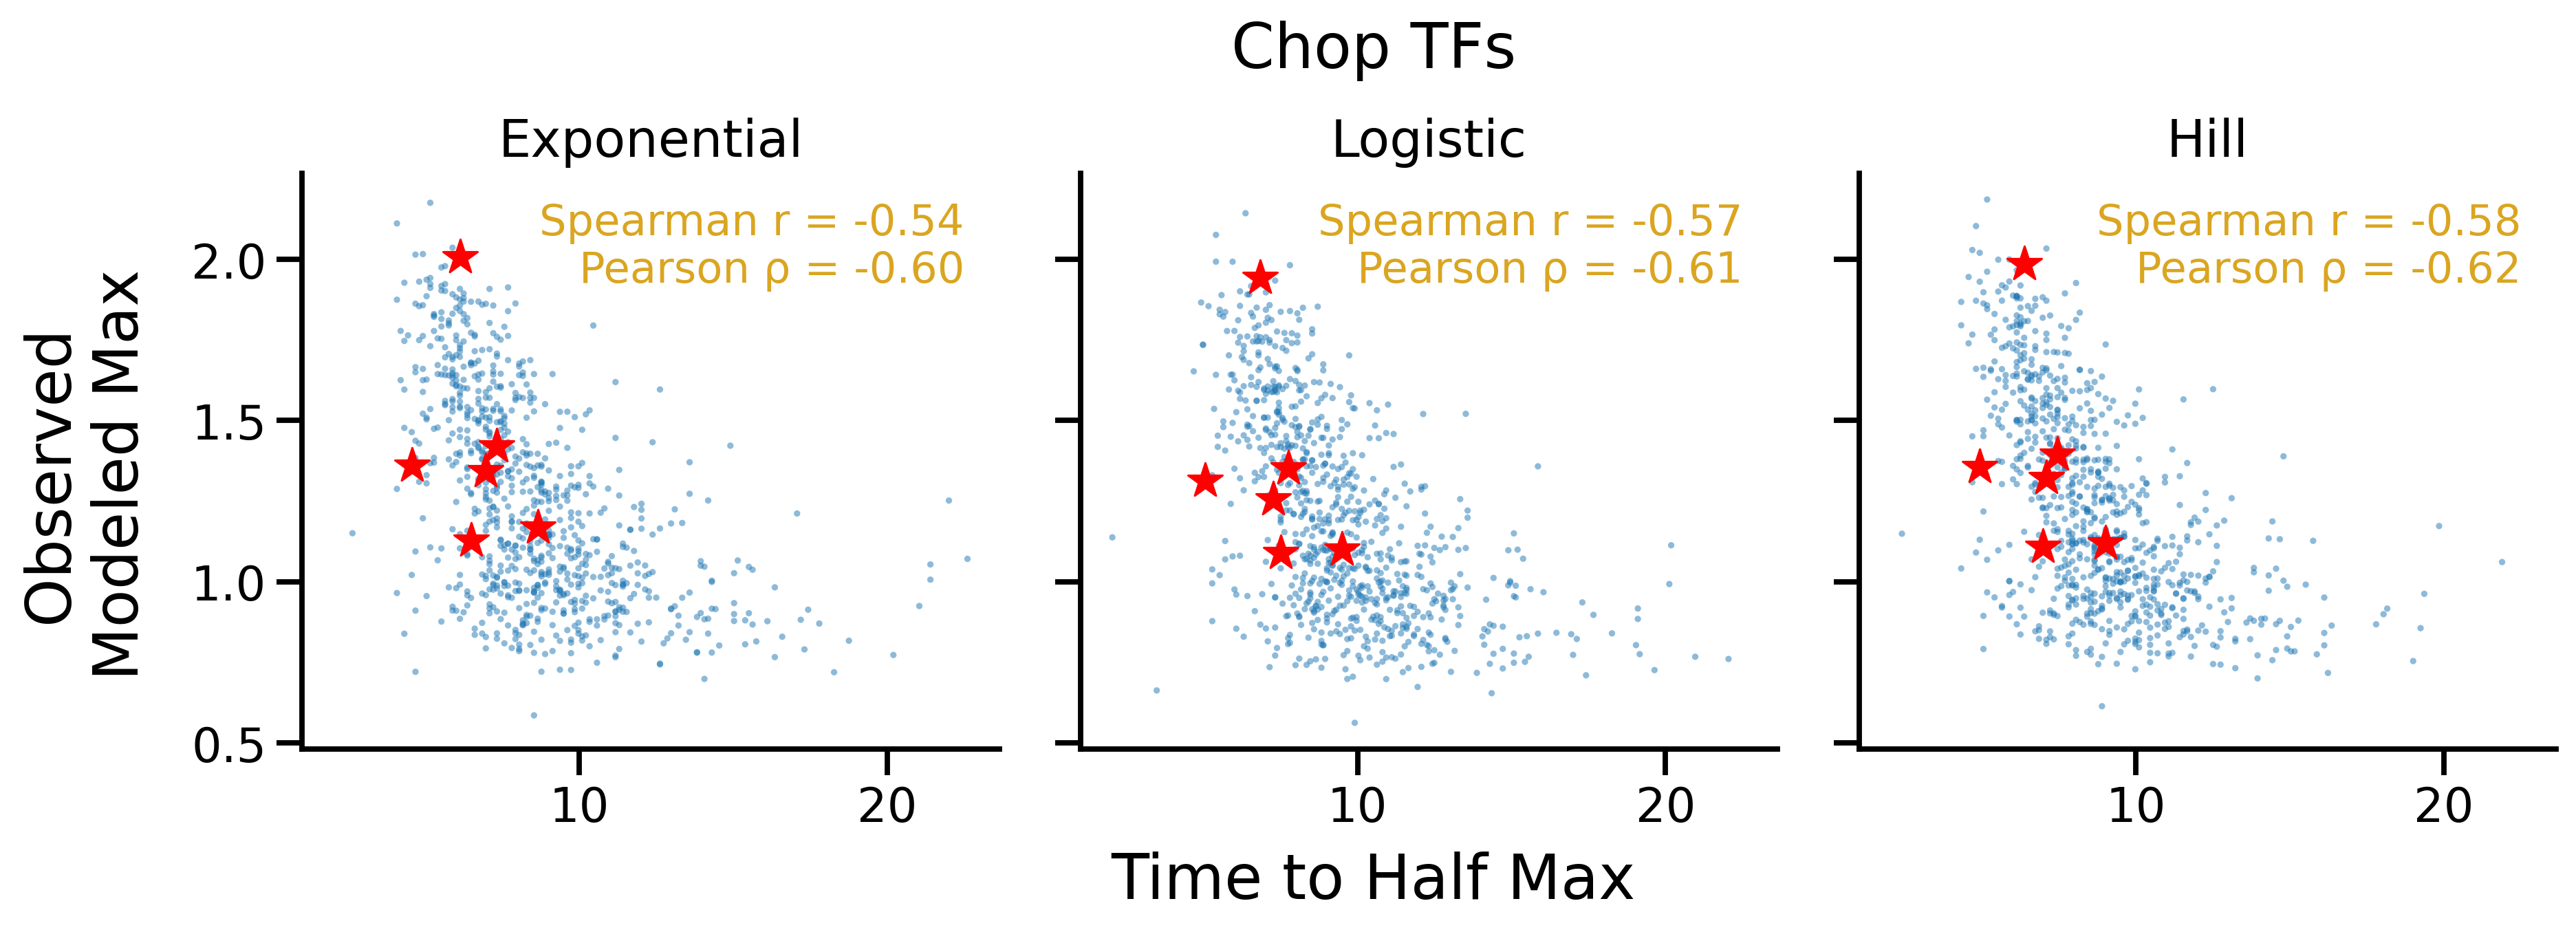

In [25]:
plot_all_model_speed_strength(selected_adseqs)

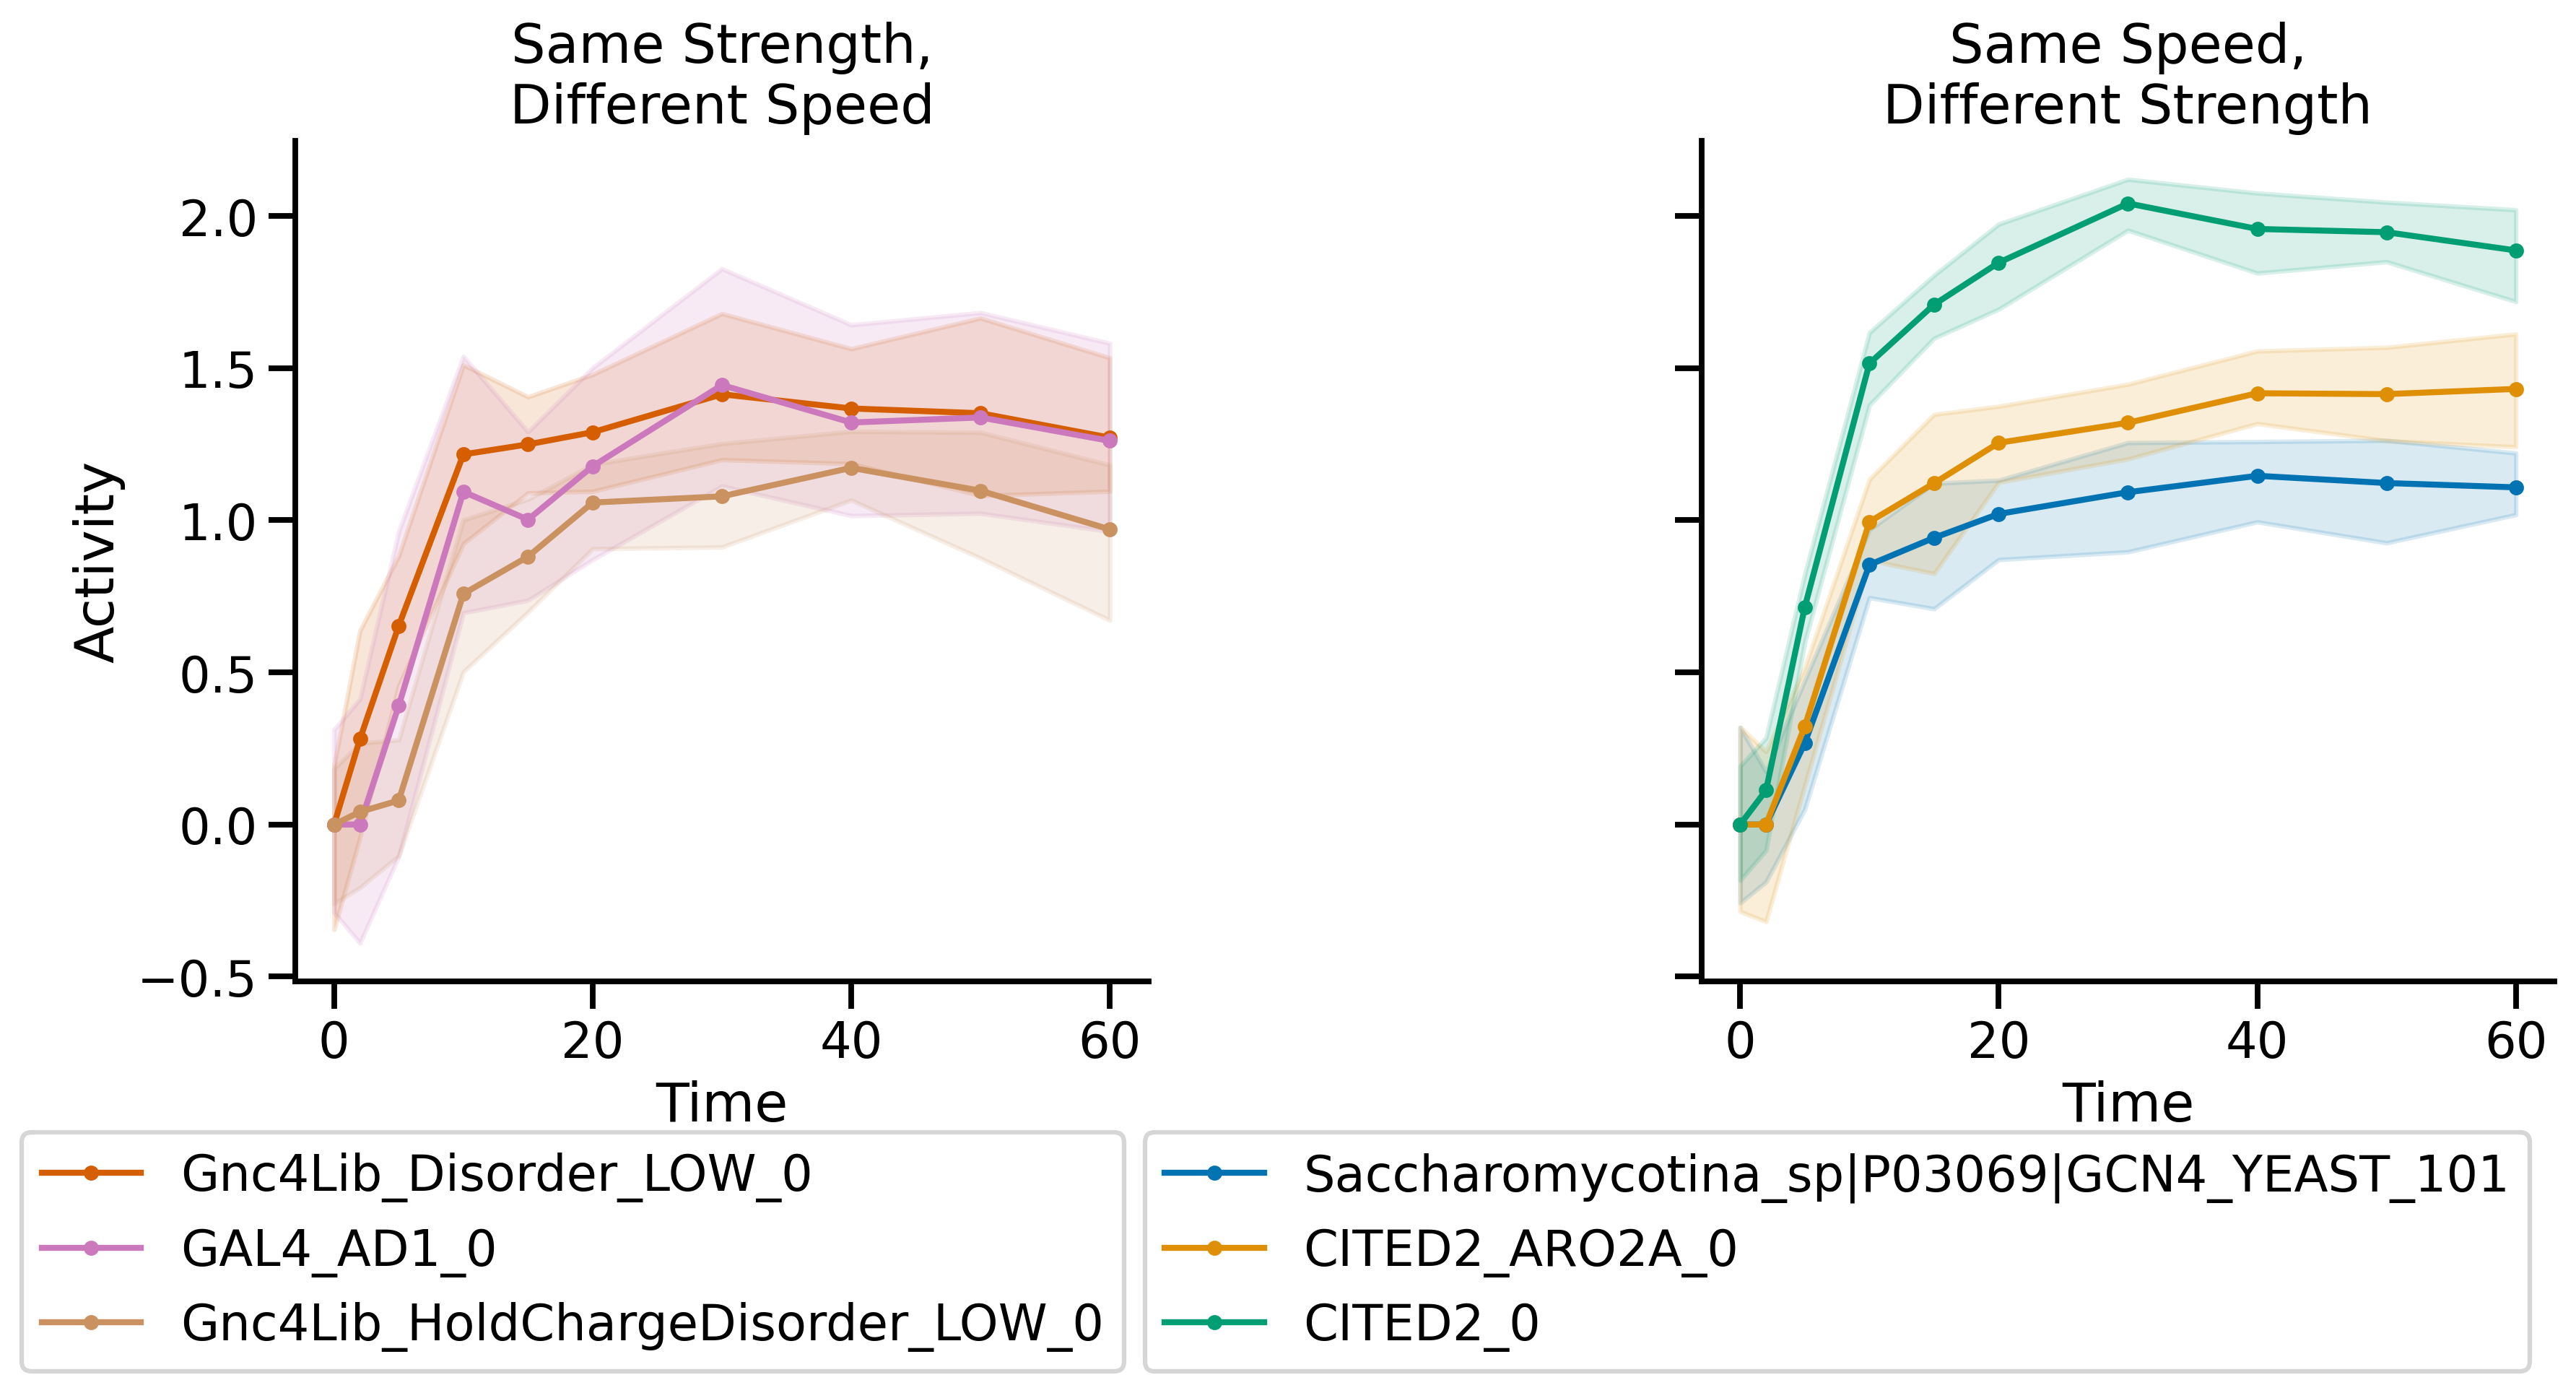

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

df = activities  # trajectory df

plot_df = df[df["ADseq"].isin(selected_adseqs)].copy()
plot_df = plot_df.sort_values(["ADseq", "time"])

# stable colors
colors = dict(zip(selected_adseqs, sns.color_palette("colorblind", n_colors=len(selected_adseqs))))

# --- enforce grouping explicitly (IMPORTANT) ---
group_strength = selected_adseqs[:3]   # same strength, different speed
group_speed = selected_adseqs[3:]  # same speed, different strength

fig, axs = plt.subplots(1, 2, figsize=(12, 7), sharey=True, dpi=300)

panels = [
    (axs[0], group_speed, "Same Strength,\nDifferent Speed"),
    (axs[1], group_strength, "Same Speed,\nDifferent Strength"),
]

for ax, group, title in panels:

    for ad in group:
        g = plot_df[plot_df["ADseq"] == ad].sort_values("time")

        t = g["time"].values
        y = g["activity_norm"].values
        lo = g["ci_low_norm"].values
        hi = g["ci_hi_norm"].values

        c = colors[ad]

        # CI band
        ax.fill_between(t, lo, hi, color=c, alpha=0.15)

        # trajectory
        ax.plot(
            t, y,
            color=c,
            linewidth=2,
            marker="o",
            markersize=4,
            label=dict(zip(chopTF_controls["ADseq"], chopTF_controls["Name"]))[ad]
        )

    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.legend(loc = 'upper right', bbox_to_anchor = (1,-0.15))
    
# shared y-axis
axs[0].set_ylabel("Activity")

# styling
for ax in axs:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()